# EXIOBASE3 hotspot analysis for Sweden with pymrio

This notebook loads the EXIOBASE3 monetary PxP IOT, calculates the missing MRIO tables with `pymrio`, and produces a Sweden-focused hotspot analysis for:

1. economic importance,
2. greenhouse-gas impacts,
3. material footprint,

for both consumption-based accounting (CBA) and production-based accounting (PBA). It also derives source-country shares for the hotspot sectors.

## Key assumptions used in this notebook

- **Economic importance** is represented by the `factor_inputs` extension row **`Value Added`**.
- **GHG impacts** are represented by the `impact` extension row **`global warming (GWP100)`** only when a characterized `impact` extension is actually available. If not, the notebook skips GHG with an explicit note rather than assuming a proxy.
- **Material footprint** is represented from the **`materials`** extension. The notebook first tries to find a single “total used-material” style row. If none is found, it sums eligible material rows after checking that the units are consistent.
- **Source-country shares for PBA sectors are trivial by definition**: for Swedish PBA hotspots, the source country is Sweden (`SE`) because PBA records impacts occurring in Swedish production sectors.
- The country-origin decomposition for **CBA** is implemented in a memory-conscious way from `S`, `L`, and Swedish final demand, rather than by fully diagonalizing a stressor, because that approach becomes very memory-intensive for full EXIOBASE systems.

## Before running

- Adjust the settings in the configuration cell if needed.
- Expect parsing and `calc_all()` on EXIOBASE to take noticeable time and memory.

In [1]:
# Optional: install missing packages from inside the notebook
# %pip install pymrio pandas numpy matplotlib openpyxl

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymrio

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# -----------------------------
# User configuration
# -----------------------------
DATA_PATH = Path(r"C:\EXIOBASE3\IOT_2024_pxp.zip")
TARGET_REGION = "SE"

TOP_N_SECTORS = 15               # ranking tables and charts
TOP_N_SOURCE_SECTORS = 5         # hotspot sectors per indicator/account to trace to countries
TOP_N_SOURCE_COUNTRIES = 10      # number of source countries shown per CBA hotspot sector
TOP_N_DESTINATION_COUNTRIES = 10 # number of destination countries shown per PBA hotspot sector

# Set this to a row label or list of row labels if you want to override
# the automatic material-footprint row selection.
# Examples:
# MATERIAL_ROW_SELECTION = "Total material extraction"
# MATERIAL_ROW_SELECTION = [("Used", "Biomass"), ("Used", "Metal ores")]
MATERIAL_ROW_SELECTION = None

# Optional manual override for value added rows when the factor_inputs extension
# does not provide a single "Value Added" total row.
VALUE_ADDED_ROW_SELECTION = None

# GHG proxy configuration used only when no characterized `impact` extension is present.
# Default factors follow common 100-year GWPs for CO2, CH4, and N2O.
GWP100_FACTORS = {
    "CO2": 1.0,
    "CH4": 28.0,
    "N2O": 265.0,
}

# Set to True if you explicitly want to include *_bio rows in the raw-emissions GHG proxy.
GHG_INCLUDE_BIOGENIC = False

# Include rows that are already reported in CO2-equivalent units (for example HFC/PFC).
GHG_INCLUDE_PRECHARACTERIZED_EQ_ROWS = True

# Include SF6 if present in physical mass units and characterize it with the configured factor.
GHG_INCLUDE_SF6 = True

# Core rows that should normally not be zero for a complete production-based fossil/combustion profile.
# These are used only for diagnostics/warnings.
GHG_CORE_DIAGNOSTIC_ROWS = [
    "CO2 - combustion - air",
    "CH4 - combustion - air",
    "N2O - combustion - air",
]

# Optional manual override for GHG rows when using the raw air-emissions extension.
# Example format:
# GHG_ROW_SELECTION = {
#     ("CO2", "combustion", "air"): 1.0,
#     ("CH4", "combustion", "air"): 28.0,
#     ("N2O", "combustion", "air"): 265.0,
# }
GHG_ROW_SELECTION = None


# Choose which GHG definition to use when both are available.
# "impact" = characterized impact extension (preferred when present)
# "proxy"  = raw-emissions proxy built from selected CO2/CH4/N2O rows
GHG_PREFERRED_SOURCE = "impact"

# When an impact extension is available and raw emissions are also available,
# build the proxy as well and compare the two definitions.
GHG_COMPARE_PROXY_WHEN_IMPACT_AVAILABLE = True

# Set to True to skip GHG results entirely unless a characterized impact
# extension is available. Useful when you want strict cross-year comparability.
GHG_FAIL_IF_ONLY_PROXY = False

# Heuristic warning threshold for the total GHG CBA/PBA ratio.
GHG_SUSPICIOUS_CBA_TO_PBA_RATIO = 5.0

OUTPUT_DIR = Path.cwd() / "exiobase3_sweden_hotspot_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



In [3]:
from types import SimpleNamespace


def row_to_text(row_label):
    """Render row labels consistently for exact matching and reporting."""
    if isinstance(row_label, tuple):
        return " | ".join(str(x) for x in row_label)
    return str(row_label)


def as_listlike(row_selector):
    if isinstance(row_selector, (list, tuple, pd.Index, np.ndarray)):
        return row_selector
    return [row_selector]


def select_rows(df, row_selector):
    """
    Safe row selection for regular and MultiIndex row labels.
    Returns a DataFrame even for a single row.
    """
    if isinstance(row_selector, tuple) and not isinstance(df.index, pd.MultiIndex):
        return df.loc[[row_selector]]
    if isinstance(row_selector, (list, pd.Index, np.ndarray)):
        return df.loc[list(row_selector)]
    return df.loc[[row_selector]]


def sum_selected_rows(df, row_selector):
    selected = select_rows(df, row_selector)
    if selected.shape[0] == 1:
        return selected.iloc[0]
    return selected.sum(axis=0)


def get_level_key(index_like, preferred_name, fallback_position):
    if isinstance(index_like, pd.MultiIndex):
        if preferred_name in (index_like.names or []):
            return preferred_name
        return fallback_position
    raise ValueError("Expected a MultiIndex.")


def split_region_sector_columns(df, target_region):
    """
    Return the sector columns for a specific region from a standard pymrio account table.
    """
    if isinstance(df.columns, pd.MultiIndex):
        level = get_level_key(df.columns, "region", 0)
        return df.xs(target_region, axis=1, level=level)
    raise ValueError("Expected a pymrio-style DataFrame with MultiIndex columns (region, sector).")


def aggregate_final_demand_by_region(Y):
    """
    Aggregate final demand categories to one column per region.
    """
    if isinstance(Y.columns, pd.MultiIndex):
        col_level = get_level_key(Y.columns, "region", 0)
        return Y.T.groupby(level=col_level, sort=False).sum().T
    return Y.copy()


def ranking_from_account(account_df, row_selector, target_region, account_name, indicator_name, unit=None):
    """
    Build a tidy ranking table for one indicator and one account type.
    """
    regional_df = split_region_sector_columns(account_df, target_region)
    values = sum_selected_rows(regional_df, row_selector).astype(float)
    values = values.sort_values(ascending=False)

    total = values.sum()
    out = (
        values.rename("value")
        .reset_index()
        .rename(columns={"index": "sector", "sector": "sector"})
    )
    if "sector" not in out.columns:
        out.columns = ["sector", "value"]

    out["account"] = account_name
    out["indicator"] = indicator_name
    out["region"] = target_region
    out["share_of_region_total"] = np.where(total != 0, out["value"] / total, np.nan)
    out["rank"] = np.arange(1, len(out) + 1)
    out["unit"] = unit
    return out[["account", "indicator", "region", "sector", "value", "share_of_region_total", "rank", "unit"]]


def _extract_units_from_selection(unit_obj, row_selector):
    if unit_obj is None:
        return []

    if isinstance(unit_obj, pd.DataFrame):
        selected = select_rows(unit_obj, row_selector)
        if selected.shape[1] == 1:
            units = selected.iloc[:, 0].astype(str).str.strip().dropna().unique().tolist()
        else:
            units = pd.unique(selected.astype(str).stack().str.strip()).tolist()
    elif isinstance(unit_obj, pd.Series):
        if isinstance(row_selector, (list, pd.Index, np.ndarray)):
            selected = unit_obj.loc[list(row_selector)]
        else:
            selected = unit_obj.loc[[row_selector]]
        units = selected.astype(str).str.strip().dropna().unique().tolist()
    else:
        return []

    return [u for u in units if u and u.lower() != "nan"]


def detect_common_unit(ext, row_selector):
    """
    Try to detect a common unit across selected extension rows.
    """
    try:
        units = _extract_units_from_selection(getattr(ext, "unit", None), row_selector)
        if len(units) == 1:
            return units[0]
        if len(units) == 0:
            return None
        raise ValueError(f"Selected rows do not have a single common unit: {units}")
    except Exception:
        return None


def get_extension_map(mrio):
    return {name: getattr(mrio, name) for name in mrio.get_extensions() if hasattr(mrio, name)}


def resolve_extension(mrio, exact=None, contains=None, row_contains=None, required=False, label="extension"):
    """
    Resolve an extension dynamically from the parsed MRIO object.
    """
    ext_map = get_extension_map(mrio)

    for candidate in (exact or []):
        if candidate in ext_map:
            return ext_map[candidate], candidate

    contains = [c.lower() for c in (contains or [])]
    if contains:
        for name, ext in ext_map.items():
            lname = name.lower()
            if any(c in lname for c in contains):
                return ext, name

    row_contains = [c.lower() for c in (row_contains or [])]
    if row_contains:
        for name, ext in ext_map.items():
            try:
                rows = [row_to_text(r).lower() for r in list(ext.get_rows())[:500]]
            except Exception:
                continue
            if any(any(token in txt for token in row_contains) for txt in rows):
                return ext, name

    if required:
        raise KeyError(
            f"Could not resolve {label}. Available extensions: {list(ext_map.keys())}"
        )
    return None, None


def preview_extension_rows(ext, n=50):
    try:
        return [row_to_text(x) for x in list(ext.get_rows())[:n]]
    except Exception:
        return []


def choose_first_matching_row(ext, exact=None, contains=None):
    """
    Return the first matching extension row using exact and substring matching.
    """
    rows = list(ext.get_rows())
    row_map = {row_to_text(r).strip().lower(): r for r in rows}

    for candidate in (exact or []):
        key = str(candidate).strip().lower()
        if key in row_map:
            return row_map[key]

    for needle in (contains or []):
        needle = str(needle).strip().lower()
        for r in rows:
            txt = row_to_text(r).strip().lower()
            if needle in txt:
                return r

    available_preview = [row_to_text(r) for r in rows[:30]]
    raise KeyError(
        "Could not find a matching row. "
        f"Exact candidates={exact}, contains candidates={contains}. "
        f"First available rows: {available_preview}"
    )


def find_rows_containing(ext, include_any, exclude_any=None):
    matches = []
    include_any = [s.lower() for s in (include_any or [])]
    exclude_any = [s.lower() for s in (exclude_any or [])]
    for row in list(ext.get_rows()):
        txt = row_to_text(row).lower()
        if include_any and not any(token in txt for token in include_any):
            continue
        if exclude_any and any(token in txt for token in exclude_any):
            continue
        matches.append(row)
    return matches


def choose_value_added_rows(factor_inputs_ext, override=None):
    """
    Resolve rows representing gross value added.
    Prefer an explicit total row; otherwise sum the component rows.
    """
    if override is not None:
        return override, "User-specified value-added row selection"

    try:
        total_row = choose_first_matching_row(
            factor_inputs_ext,
            exact=["Value Added", "value added"],
            contains=["value added"],
        )
        return total_row, f"Automatically selected value-added total row: {row_to_text(total_row)}"
    except Exception:
        pass

    component_rows = find_rows_containing(
        factor_inputs_ext,
        include_any=[
            "taxes less subsidies",
            "other net taxes",
            "compensation of employees",
            "operating surplus",
            "mixed income",
        ],
        exclude_any=[],
    )

    if component_rows:
        return component_rows, "No single value-added total row found; summing value-added component rows"

    all_rows = list(factor_inputs_ext.get_rows())
    return all_rows, "No explicit value-added row pattern found; summing all factor-input rows"



def choose_material_rows(materials_ext, override=None):
    """
    Heuristic material-row selector.

    Strategy:
    1. Use explicit override if provided.
    2. Prefer an explicit total used-material row when it exists.
    3. Otherwise sum rows starting with 'Domestic Extraction Used -'.
    4. Exclude rows that look like totals when detailed rows are selected, to avoid double counting.
    """
    if override is not None:
        return override, "User-specified material row selection"

    rows = list(materials_ext.get_rows())
    row_text = pd.Series({row: row_to_text(row).lower() for row in rows})

    exact_total_candidates = []
    for row, txt in row_text.items():
        if (
            "domestic extraction used" in txt
            and (
                txt.strip() == "domestic extraction used"
                or txt.endswith(" - total")
                or " total " in txt
                or txt.startswith("total ")
            )
        ):
            exact_total_candidates.append(row)

    if len(exact_total_candidates) == 1:
        return exact_total_candidates[0], f"Automatically selected material total row: {row_to_text(exact_total_candidates[0])}"

    used_rows = []
    for row, txt in row_text.items():
        if not txt.startswith("domestic extraction used"):
            continue
        if "unused" in txt:
            continue
        if txt.strip() == "domestic extraction used":
            continue
        if "total" in txt:
            continue
        used_rows.append(row)

    if len(used_rows) > 0:
        return used_rows, "Automatically selected detailed 'Domestic Extraction Used' rows and summed them"

    unit = detect_common_unit(materials_ext, rows)
    if unit is not None:
        return rows, "No clear material-total row found; summing all material rows because units appear consistent"

    raise ValueError(
        "Could not determine a safe material-footprint row selection automatically. "
        "Inspect the material extension rows and set MATERIAL_ROW_SELECTION explicitly."
    )



def choose_ghg_row_factors(
    emissions_ext,
    override=None,
    default_factors=None,
    include_biogenic=False,
    include_precharacterized_eq_rows=True,
    include_sf6=True,
):
    """
    Build a transparent GHG row-to-factor mapping from the air-emissions extension.

    Included by default:
    - CO2, CH4, N2O rows in physical mass units
    - HFC/PFC rows already reported in CO2-eq units (factor 1)
    - SF6 if present (using the configured factor)

    Excluded by default:
    - biogenic rows when include_biogenic=False
    - rows whose text suggests they are already aggregated impacts (e.g. GWP / CO2-equivalent)
      for CO2/CH4/N2O matching
    """
    if override is not None:
        return override, "User-specified GHG row selection"

    default_factors = default_factors or {"CO2": 1.0, "CH4": 28.0, "N2O": 265.0}
    row_factor_map = {}
    notes = []

    gas_patterns = {
        "CO2": ["carbon dioxide", "co2"],
        "CH4": ["methane", "ch4"],
        "N2O": ["nitrous oxide", "n2o"],
    }

    gas_excludes = {
        "CO2": ["co2-equivalent", "co2 equivalent", "kg co2-eq", "gwp"],
        "CH4": ["co2-equivalent", "co2 equivalent", "kg co2-eq", "gwp"],
        "N2O": ["nitrogen oxides", "nox", "co2-equivalent", "co2 equivalent", "kg co2-eq", "gwp"],
    }

    if not include_biogenic:
        for gas in gas_excludes:
            gas_excludes[gas] = list(gas_excludes[gas]) + ["_bio", " biogenic "]

    # First: physical-mass CO2/CH4/N2O rows
    for gas, patterns in gas_patterns.items():
        rows = find_rows_containing(emissions_ext, include_any=patterns, exclude_any=gas_excludes.get(gas))
        matched = []
        for row in rows:
            unit = str(detect_common_unit(emissions_ext, row) or "").lower()
            # Keep physical rows; skip already-equivalent rows here to avoid double counting
            if "co2-eq" in unit or "co2 eq" in unit:
                continue
            row_factor_map[row] = float(default_factors[gas])
            matched.append(row)
        if matched:
            notes.append(f"{gas}: {len(matched)} physical row(s)")
        else:
            notes.append(f"{gas}: no physical row found")

    # Second: already-characterized HFC/PFC rows
    if include_precharacterized_eq_rows:
        for gas in ["HFC", "PFC"]:
            rows = find_rows_containing(emissions_ext, include_any=[gas.lower()], exclude_any=[])
            matched = []
            for row in rows:
                unit = str(detect_common_unit(emissions_ext, row) or "").lower()
                if "co2-eq" in unit or "co2 eq" in unit:
                    row_factor_map[row] = 1.0
                    matched.append(row)
            if matched:
                notes.append(f"{gas}: {len(matched)} CO2-eq row(s) included with factor 1")
            else:
                notes.append(f"{gas}: no CO2-eq row found")

    # Third: SF6 physical rows
    if include_sf6:
        rows = find_rows_containing(emissions_ext, include_any=["sf6"], exclude_any=[])
        matched = []
        for row in rows:
            unit = str(detect_common_unit(emissions_ext, row) or "").lower()
            if "co2-eq" in unit or "co2 eq" in unit:
                row_factor_map[row] = 1.0
                matched.append(row)
            elif "SF6" in default_factors:
                row_factor_map[row] = float(default_factors["SF6"])
                matched.append(row)
        if matched:
            notes.append(f"SF6: {len(matched)} row(s) included")
        else:
            notes.append("SF6: no row found")

    if not row_factor_map:
        preview = preview_extension_rows(emissions_ext, n=80)
        raise ValueError(
            "Could not identify any configured GHG rows in the emissions extension. "
            f"First rows: {preview}"
        )

    if not include_biogenic:
        notes.append("biogenic rows excluded by configuration")

    return row_factor_map, "Automatically built raw-emissions GHG proxy using " + ", ".join(notes)


def characterize_account_from_row_factors(account_df, row_factor_map, row_name):
    pieces = []
    for row, factor in row_factor_map.items():
        piece = select_rows(account_df, row).astype(float) * float(factor)
        pieces.append(piece)
    combined = pd.concat(pieces, axis=0).groupby(level=0).sum() if len(pieces) > 1 else pieces[0]
    if isinstance(combined, pd.DataFrame) and combined.shape[0] > 1:
        combined = combined.sum(axis=0)
    elif isinstance(combined, pd.DataFrame) and combined.shape[0] == 1:
        combined = combined.iloc[0]
    return pd.DataFrame([combined], index=pd.Index([row_name], name="impact"))



def build_characterized_proxy_extension(ext, row_factor_map, row_name="GHG proxy", impact_unit="kg CO2-eq"):
    proxy = SimpleNamespace()
    proxy.name = row_name
    proxy.S = characterize_account_from_row_factors(ext.S, row_factor_map, row_name)
    proxy.unit = pd.DataFrame({"unit": [impact_unit]}, index=pd.Index([row_name], name="impact"))
    proxy.D_cba = None
    proxy.D_pba = None
    return proxy


def as_series(vector_like):
    if isinstance(vector_like, pd.DataFrame):
        if vector_like.shape[1] == 1:
            return vector_like.iloc[:, 0].astype(float)
        raise ValueError("Expected a Series-like object or a single-column DataFrame.")
    if isinstance(vector_like, pd.Series):
        return vector_like.astype(float)
    return pd.Series(vector_like, dtype=float)


def get_output_vector(mrio):
    if hasattr(mrio, "x") and mrio.x is not None:
        return as_series(mrio.x)
    return as_series(mrio.L.dot(mrio.Y.sum(axis=1)))


def selected_S_vector(ext, row_selector):
    return sum_selected_rows(ext.S, row_selector).astype(float)


def manual_cba_sector_vector(mrio, ext, row_selector, target_region, Y_agg):
    """
    Compute sector-specific CBA directly from S, L, and aggregated Y.

    For one destination region, multiply the multiplier vector M = S @ L
    with the destination-region final-demand column and group by sector.
    """
    S_vec = selected_S_vector(ext, row_selector)
    M_vec = as_series(S_vec.dot(mrio.L))
    y_reg = as_series(Y_agg[target_region])

    if not M_vec.index.equals(y_reg.index):
        y_reg = y_reg.reindex(M_vec.index)

    sector_level = get_level_key(M_vec.index, "sector", 1)
    sector_values = (M_vec * y_reg).groupby(level=sector_level).sum().sort_values(ascending=False)
    return sector_values.astype(float)


def manual_pba_sector_vector(mrio, ext, row_selector, target_region):
    """
    Compute sector-specific PBA directly from S and x.
    """
    S_vec = selected_S_vector(ext, row_selector)
    x_vec = get_output_vector(mrio)

    if not S_vec.index.equals(x_vec.index):
        x_vec = x_vec.reindex(S_vec.index)

    direct = (S_vec * x_vec).astype(float)
    region_level = get_level_key(direct.index, "region", 0)
    sector_level = get_level_key(direct.index, "sector", 1)
    region_direct = direct.xs(target_region, level=region_level)
    if isinstance(region_direct.index, pd.MultiIndex):
        region_direct = region_direct.groupby(level=sector_level).sum()
    region_direct = region_direct.sort_values(ascending=False)
    return region_direct.astype(float)


def manual_account_value(mrio, ext, row_selector, account_name, target_region, target_sector, Y_agg):
    if account_name == "CBA":
        vec = manual_cba_sector_vector(mrio, ext, row_selector, target_region, Y_agg)
    elif account_name == "PBA":
        vec = manual_pba_sector_vector(mrio, ext, row_selector, target_region)
    else:
        raise ValueError("account_name must be 'CBA' or 'PBA'")
    return float(vec.loc[target_sector])


def ranking_from_manual_account(mrio, ext, row_selector, target_region, account_name, indicator_name, Y_agg, unit=None):
    """
    Build a tidy ranking table using manual S/L/Y definitions instead of relying on stored D_cba/D_pba.
    """
    if account_name == "CBA":
        values = manual_cba_sector_vector(mrio, ext, row_selector, target_region, Y_agg)
    elif account_name == "PBA":
        values = manual_pba_sector_vector(mrio, ext, row_selector, target_region)
    else:
        raise ValueError("account_name must be 'CBA' or 'PBA'")

    total = values.sum()
    out = values.rename("value").reset_index()
    if "sector" not in out.columns:
        out.columns = ["sector", "value"]

    out["account"] = account_name
    out["indicator"] = indicator_name
    out["region"] = target_region
    out["share_of_region_total"] = np.where(total != 0, out["value"] / total, np.nan)
    out["rank"] = np.arange(1, len(out) + 1)
    out["unit"] = unit
    return out[["account", "indicator", "region", "sector", "value", "share_of_region_total", "rank", "unit"]]


def summarize_tail_with_other(df, country_col, value_col, share_col, total_value, top_n, force_include=None):
    """
    Keep the largest countries, optionally force-include specific ones, and add an OTHER row for the remainder.
    """
    work = df.copy()
    force_include = force_include or []
    work = work.sort_values(value_col, ascending=False).reset_index(drop=True)

    if top_n is None or top_n >= len(work):
        return work.reset_index(drop=True)

    forced = work[work[country_col].isin(force_include)]
    top = work.head(top_n)
    kept = pd.concat([top, forced], ignore_index=True).drop_duplicates(subset=[country_col]).reset_index(drop=True)

    kept_value = float(kept[value_col].sum())
    other_value = float(total_value - kept_value)

    if abs(other_value) > 1e-12:
        other_row = {col: kept.iloc[0][col] if len(kept) else np.nan for col in kept.columns}
        other_row[country_col] = "OTHER"
        other_row[value_col] = other_value
        other_row[share_col] = other_value / total_value if total_value != 0 else np.nan
        kept = pd.concat([kept, pd.DataFrame([other_row])], ignore_index=True)

    return kept.reset_index(drop=True)


def compare_extension_and_manual_accounts(mrio, ext, row_selector, target_region, Y_agg, indicator_name):
    rows = []

    # manual accounts
    cba_manual = manual_cba_sector_vector(mrio, ext, row_selector, target_region, Y_agg)
    pba_manual = manual_pba_sector_vector(mrio, ext, row_selector, target_region)

    # extension accounts if available
    if getattr(ext, "D_cba", None) is not None:
        try:
            cba_ext = sum_selected_rows(split_region_sector_columns(ext.D_cba, target_region), row_selector).astype(float)
            cba_ext = cba_ext.reindex(cba_manual.index)
            rows.append({
                "indicator": indicator_name,
                "account": "CBA",
                "manual_total": float(cba_manual.sum()),
                "extension_total": float(cba_ext.sum()),
                "difference": float(cba_manual.sum() - cba_ext.sum()),
                "relative_difference": float((cba_manual.sum() - cba_ext.sum()) / cba_manual.sum()) if float(cba_manual.sum()) != 0 else np.nan,
            })
        except Exception:
            pass

    if getattr(ext, "D_pba", None) is not None:
        try:
            pba_ext = sum_selected_rows(split_region_sector_columns(ext.D_pba, target_region), row_selector).astype(float)
            pba_ext = pba_ext.reindex(pba_manual.index)
            rows.append({
                "indicator": indicator_name,
                "account": "PBA",
                "manual_total": float(pba_manual.sum()),
                "extension_total": float(pba_ext.sum()),
                "difference": float(pba_manual.sum() - pba_ext.sum()),
                "relative_difference": float((pba_manual.sum() - pba_ext.sum()) / pba_manual.sum()) if float(pba_manual.sum()) != 0 else np.nan,
            })
        except Exception:
            pass

    return pd.DataFrame(rows)



def build_final_demand_vector_for_region_sector(Y_agg, target_region, target_sector):
    """
    Build the sector-specific final-demand vector that matches pymrio.calc_accounts'
    diagonalization logic: all source regions supplying one sector to one destination region.
    """
    if not isinstance(Y_agg.index, pd.MultiIndex):
        raise ValueError("Expected Y_agg rows to be a MultiIndex of (region, sector).")

    sector_level = get_level_key(Y_agg.index, "sector", 1)
    y_target = pd.Series(0.0, index=Y_agg.index, dtype=float)

    mask = Y_agg.index.get_level_values(sector_level) == target_sector
    y_target.loc[mask] = Y_agg.loc[mask, target_region].astype(float).to_numpy()
    return y_target


def extract_account_value(account_df, row_selector, target_region, target_sector):
    values = sum_selected_rows(account_df, row_selector).astype(float)
    return float(values.loc[(target_region, target_sector)])



def cba_source_country_shares(mrio, ext, row_selector, target_region, target_sector, Y_agg, top_n=10):
    """
    Attribute the CBA of one (target_region, target_sector) column to source countries.
    """
    y_target = build_final_demand_vector_for_region_sector(Y_agg, target_region, target_sector)
    x_source = as_series(mrio.L.dot(y_target)).rename("required_output")
    selected_S = selected_S_vector(ext, row_selector)

    if not selected_S.index.equals(x_source.index):
        x_source = x_source.reindex(selected_S.index)

    source_vector = (selected_S * x_source).rename("source_value")
    region_level = get_level_key(source_vector.index, "region", 0)

    country_totals = source_vector.groupby(level=region_level).sum().sort_values(ascending=False)
    total = float(country_totals.sum())

    full = country_totals.reset_index()
    full.columns = ["source_country", "source_value"]
    full["source_share"] = np.where(total != 0, full["source_value"] / total, np.nan)
    full["target_region"] = target_region
    full["target_sector"] = target_sector
    full["model_total"] = total
    full["residual_to_model_total"] = full["source_value"].sum() - total
    full = full[[
        "target_region",
        "target_sector",
        "source_country",
        "source_value",
        "source_share",
        "model_total",
        "residual_to_model_total",
    ]]

    shown = summarize_tail_with_other(
        full,
        country_col="source_country",
        value_col="source_value",
        share_col="source_share",
        total_value=total,
        top_n=top_n,
        force_include=[target_region],
    )
    shown["target_region"] = target_region
    shown["target_sector"] = target_sector
    shown["model_total"] = total
    shown["residual_to_model_total"] = shown["source_value"].sum() - total
    shown = shown[[
        "target_region",
        "target_sector",
        "source_country",
        "source_value",
        "source_share",
        "model_total",
        "residual_to_model_total",
    ]]

    return full.reset_index(drop=True), shown.reset_index(drop=True)



def pba_destination_country_shares(mrio, ext, row_selector, source_region, source_sector, Y_agg, top_n=10):
    """
    Allocate the direct PBA of one production sector across destination countries'
    final demand using the output decomposition x = L @ y_country.

    Important: this is a *final-demand destination* allocation, not a direct export-
    partner table. A Swedish sector can therefore have foreign destination shares even
    when its immediate exports are limited, because the sector can supply upstream
    value chains that ultimately satisfy final demand abroad.
    """
    if not isinstance(Y_agg.columns, pd.Index):
        raise ValueError("Expected Y_agg columns to be a single Index of destination regions.")

    output_by_destination = mrio.L.dot(Y_agg.astype(float))
    source_output_by_destination = as_series(output_by_destination.loc[(source_region, source_sector)])

    selected_S = selected_S_vector(ext, row_selector)
    direct_coeff = float(selected_S.loc[(source_region, source_sector)])

    destination_values = (source_output_by_destination * direct_coeff).sort_values(ascending=False)
    total = float(destination_values.sum())

    full = destination_values.rename("destination_value").reset_index()
    full.columns = ["destination_country", "destination_value"]
    full["destination_share"] = np.where(total != 0, full["destination_value"] / total, np.nan)
    full["source_region"] = source_region
    full["source_sector"] = source_sector
    full["model_total"] = total
    full["residual_to_model_total"] = full["destination_value"].sum() - total
    full = full[[
        "source_region",
        "source_sector",
        "destination_country",
        "destination_value",
        "destination_share",
        "model_total",
        "residual_to_model_total",
    ]]

    shown = summarize_tail_with_other(
        full,
        country_col="destination_country",
        value_col="destination_value",
        share_col="destination_share",
        total_value=total,
        top_n=top_n,
        force_include=[source_region],
    )
    shown["source_region"] = source_region
    shown["source_sector"] = source_sector
    shown["model_total"] = total
    shown["residual_to_model_total"] = shown["destination_value"].sum() - total
    shown = shown[[
        "source_region",
        "source_sector",
        "destination_country",
        "destination_value",
        "destination_share",
        "model_total",
        "residual_to_model_total",
    ]]

    return full.reset_index(drop=True), shown.reset_index(drop=True)



def summarise_breakdown_quality(
    df,
    group_cols,
    value_col,
    total_col,
    reference_total_col=None,
    share_col=None,
    atol=1e-6,
    rtol=1e-9,
):
    """
    Summarise whether a country breakdown closes back to the model total.

    Parameters
    ----------
    df : DataFrame
        Full (not truncated) breakdown table.
    group_cols : list[str]
        Columns identifying one hotspot sector.
    value_col : str
        Contribution value column to sum.
    total_col : str
        Column containing the model total repeated on each row.
    reference_total_col : str, optional
        Additional reference total to compare against, e.g. the sector value shown
        in the ranking table.
    share_col : str, optional
        If provided, also report the summed shares.
    atol, rtol : float
        Absolute and relative tolerances for pass/fail flags.
    """
    agg_spec = {
        "reconstructed_total": (value_col, "sum"),
        "model_total": (total_col, "first"),
        "min_contribution": (value_col, "min"),
        "max_contribution": (value_col, "max"),
        "negative_contribution_count": (value_col, lambda s: int((pd.Series(s) < 0).sum())),
    }
    if reference_total_col is not None and reference_total_col in df.columns:
        agg_spec["reference_total"] = (reference_total_col, "first")
    if share_col is not None and share_col in df.columns:
        agg_spec["share_sum"] = (share_col, "sum")

    summary = (
        df.groupby(group_cols, dropna=False)
        .agg(**agg_spec)
        .reset_index()
    )

    summary["abs_difference"] = summary["reconstructed_total"] - summary["model_total"]
    summary["relative_difference"] = np.where(
        summary["model_total"] != 0,
        summary["abs_difference"] / summary["model_total"],
        np.nan,
    )
    summary["passes_model_total_check"] = (
        summary["abs_difference"].abs()
        <= (atol + rtol * summary["model_total"].abs())
    )

    if "reference_total" in summary.columns:
        summary["difference_to_reference"] = summary["reconstructed_total"] - summary["reference_total"]
        summary["relative_difference_to_reference"] = np.where(
            summary["reference_total"] != 0,
            summary["difference_to_reference"] / summary["reference_total"],
            np.nan,
        )
        summary["passes_reference_check"] = (
            summary["difference_to_reference"].abs()
            <= (atol + rtol * summary["reference_total"].abs())
        )

    if "share_sum" in summary.columns:
        summary["share_sum_difference_from_1"] = summary["share_sum"] - 1.0
        summary["passes_share_sum_check"] = summary["share_sum_difference_from_1"].abs() <= (10 * rtol)

    return summary



def plot_top_sectors(df, title, top_n=15):
    """
    Simple horizontal bar chart for the top sectors.
    """
    plot_df = df.head(top_n).sort_values("value", ascending=True)

    plt.figure(figsize=(10, max(5, 0.35 * len(plot_df))))
    plt.barh(plot_df["sector"], plot_df["value"])
    plt.title(title)
    plt.xlabel(plot_df["unit"].dropna().iloc[0] if "unit" in df.columns and df["unit"].notna().any() else "value")
    plt.tight_layout()
    plt.show()




def compare_two_sector_vectors(vec_a, vec_b, label_a="A", label_b="B", top_n=15):
    aligned = pd.concat(
        [vec_a.rename(label_a), vec_b.rename(label_b)],
        axis=1,
    ).fillna(0.0)
    aligned["difference"] = aligned[label_b] - aligned[label_a]
    aligned["ratio"] = np.where(aligned[label_a] != 0, aligned[label_b] / aligned[label_a], np.nan)

    top_overlap = len(set(vec_a.sort_values(ascending=False).head(top_n).index) & set(vec_b.sort_values(ascending=False).head(top_n).index))
    top_union = len(set(vec_a.sort_values(ascending=False).head(top_n).index) | set(vec_b.sort_values(ascending=False).head(top_n).index))
    spearman_like = aligned[label_a].rank(ascending=False, method="average").corr(
        aligned[label_b].rank(ascending=False, method="average"),
        method="pearson",
    )

    summary = pd.DataFrame([{
        "top_n": top_n,
        f"{label_a}_total": float(vec_a.sum()),
        f"{label_b}_total": float(vec_b.sum()),
        "difference_total": float(vec_b.sum() - vec_a.sum()),
        "ratio_total": float(vec_b.sum() / vec_a.sum()) if float(vec_a.sum()) != 0 else np.nan,
        "top_n_overlap_count": int(top_overlap),
        "top_n_jaccard": float(top_overlap / top_union) if top_union else np.nan,
        "rank_correlation_like_spearman": float(spearman_like) if pd.notna(spearman_like) else np.nan,
        f"top1_{label_a}": vec_a.sort_values(ascending=False).index[0] if len(vec_a) else None,
        f"top1_{label_b}": vec_b.sort_values(ascending=False).index[0] if len(vec_b) else None,
    }])

    details = (
        aligned
        .sort_values(label_b, ascending=False)
        .reset_index()
        .rename(columns={"index": "sector", "sector": "sector"})
    )
    if "sector" not in details.columns:
        details.columns = ["sector", label_a, label_b, "difference", "ratio"]
    return summary, details



def ghg_proxy_row_diagnostics(mrio, emissions_ext, row_factor_map, target_region, Y_agg):
    """
    Row-level diagnostics computed through the same proxy-building path as the main ranking logic.
    This avoids mismatches between the aggregate proxy and per-row diagnostics.
    """
    rows = []
    for raw_row, factor in row_factor_map.items():
        temp_ext = build_characterized_proxy_extension(
            emissions_ext,
            row_factor_map={raw_row: factor},
            row_name=f"diag::{row_to_text(raw_row)}",
            impact_unit=detect_common_unit(emissions_ext, raw_row) or "kg CO2-eq",
        )
        cba_total = float(manual_cba_sector_vector(mrio, temp_ext, temp_ext.name, target_region, Y_agg).sum())
        pba_total = float(manual_pba_sector_vector(mrio, temp_ext, temp_ext.name, target_region).sum())
        rows.append({
            "raw_row": row_to_text(raw_row),
            "factor": float(factor),
            "cba_total_weighted": cba_total,
            "pba_total_weighted": pba_total,
        })
    out = pd.DataFrame(rows)
    if not out.empty:
        out["cba_share_of_proxy_total"] = np.where(
            out["cba_total_weighted"].sum() != 0,
            out["cba_total_weighted"] / out["cba_total_weighted"].sum(),
            np.nan,
        )
        out["pba_share_of_proxy_total"] = np.where(
            out["pba_total_weighted"].sum() != 0,
            out["pba_total_weighted"] / out["pba_total_weighted"].sum(),
            np.nan,
        )
        out = out.sort_values("cba_total_weighted", ascending=False).reset_index(drop=True)
    return out


def ghg_core_row_check_table(mrio, emissions_ext, row_factor_map, target_region, Y_agg, core_rows=None):
    """
    Diagnostic check for key rows that should usually carry non-zero Swedish GHG totals.
    """
    core_rows = core_rows or []
    diagnostics = []
    available_rows = {row_to_text(r): r for r in list(row_factor_map.keys())}

    for label in core_rows:
        raw_row = available_rows.get(label)
        if raw_row is None:
            diagnostics.append({
                "raw_row": label,
                "selected_in_proxy": False,
                "factor": np.nan,
                "cba_total_weighted": np.nan,
                "pba_total_weighted": np.nan,
                "both_zero": np.nan,
                "warning": "row not selected in proxy",
            })
            continue

        factor = row_factor_map[raw_row]
        temp_ext = build_characterized_proxy_extension(
            emissions_ext,
            row_factor_map={raw_row: factor},
            row_name=f"diag::{label}",
            impact_unit=detect_common_unit(emissions_ext, raw_row) or "kg CO2-eq",
        )
        cba_total = float(manual_cba_sector_vector(mrio, temp_ext, temp_ext.name, target_region, Y_agg).sum())
        pba_total = float(manual_pba_sector_vector(mrio, temp_ext, temp_ext.name, target_region).sum())
        diagnostics.append({
            "raw_row": label,
            "selected_in_proxy": True,
            "factor": float(factor),
            "cba_total_weighted": cba_total,
            "pba_total_weighted": pba_total,
            "both_zero": bool(abs(cba_total) == 0 and abs(pba_total) == 0),
            "warning": "selected but zero in both CBA and PBA" if (abs(cba_total) == 0 and abs(pba_total) == 0) else "",
        })

    return pd.DataFrame(diagnostics)


def ghg_sanity_check_table(rankings, indicator_key="ghg", suspicious_ratio=5.0):
    subset = rankings.query("indicator == @indicator_key").copy()
    if subset.empty:
        return pd.DataFrame()
    totals = subset.groupby("account")["value"].sum().to_dict()
    cba_total = float(totals.get("CBA", np.nan))
    pba_total = float(totals.get("PBA", np.nan))
    ratio = cba_total / pba_total if pd.notna(cba_total) and pd.notna(pba_total) and pba_total != 0 else np.nan
    cba_top = subset.query("account == 'CBA'").sort_values("rank").head(1)
    pba_top = subset.query("account == 'PBA'").sort_values("rank").head(1)
    return pd.DataFrame([{
        "indicator": indicator_key,
        "cba_total": cba_total,
        "pba_total": pba_total,
        "cba_to_pba_ratio": ratio,
        "suspicious_ratio_threshold": suspicious_ratio,
        "ratio_exceeds_threshold": bool(pd.notna(ratio) and ratio > suspicious_ratio),
        "top_cba_sector": cba_top["sector"].iloc[0] if not cba_top.empty else None,
        "top_cba_sector_share": float(cba_top["share_of_region_total"].iloc[0]) if not cba_top.empty else np.nan,
        "top_pba_sector": pba_top["sector"].iloc[0] if not pba_top.empty else None,
        "top_pba_sector_share": float(pba_top["share_of_region_total"].iloc[0]) if not pba_top.empty else np.nan,
    }])



In [4]:
# Check that the file exists before starting heavy calculations
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find EXIOBASE at: {DATA_PATH}\n"
        "Update DATA_PATH in the configuration cell to match your local file."
    )

print(f"Loading EXIOBASE from: {DATA_PATH}")
mrio = pymrio.parse_exiobase3(DATA_PATH)

print("Calculating missing MRIO tables and accounts. This can take substantial time and memory.")
mrio.calc_all()

print("Loaded regions:", len(mrio.get_regions()))
print("Loaded sectors:", len(mrio.get_sectors()))
print("Extensions:", list(mrio.get_extensions()))

Loading EXIOBASE from: C:\EXIOBASE3\IOT_2024_pxp.zip
Calculating missing MRIO tables and accounts. This can take substantial time and memory.
Loaded regions: 49
Loaded sectors: 200
Extensions: ['air_emissions', 'water', 'land', 'material', 'nutrients', 'factor_inputs']


In [5]:

# Basic checks and dynamic extension inspection
assert TARGET_REGION in mrio.get_regions(), f"{TARGET_REGION} is not a valid EXIOBASE region code."

ext_map = get_extension_map(mrio)
print("Available extensions:")
display(pd.DataFrame({"extension": list(ext_map.keys())}))

factor_inputs_ext, factor_inputs_name = resolve_extension(
    mrio,
    exact=["factor_inputs", "factor_input"],
    contains=["factor_input"],
    row_contains=["value added"],
    required=True,
    label="factor-input extension",
)

materials_ext, materials_name = resolve_extension(
    mrio,
    exact=["materials", "material"],
    contains=["material", "resource"],
    row_contains=["biomass", "metal ores", "non-metallic minerals", "domestic extraction", "material"],
    required=False,
    label="material extension",
)

impact_ext, impact_name = resolve_extension(
    mrio,
    exact=["impact", "impacts"],
    contains=["impact"],
    row_contains=["global warming", "gwp100"],
    required=False,
    label="impact extension",
)

emissions_ext, emissions_name = resolve_extension(
    mrio,
    exact=["air_emissions", "emissions", "satellite"],
    contains=["air_emission", "emission", "satellite"],
    row_contains=["carbon dioxide", "methane", "nitrous oxide", "co2", "ch4", "n2o"],
    required=False,
    label="emissions extension",
)

print(f"Resolved factor-input extension: {factor_inputs_name}")
if materials_ext is not None:
    print(f"Resolved material extension: {materials_name}")
else:
    print("Could not resolve a dedicated material extension automatically.")

if impact_ext is not None:
    print(f"Resolved impact extension: {impact_name}")
else:
    print("No characterized impact extension found.")

if emissions_ext is not None:
    print(f"Resolved emissions extension: {emissions_name}")
else:
    print("No raw emissions extension found.")

print("Factor input rows (first 30):")
display(pd.DataFrame({"factor_input_row": preview_extension_rows(factor_inputs_ext, 30)}))

if materials_ext is not None:
    print("Material extension rows (first 50):")
    display(pd.DataFrame({"material_row": preview_extension_rows(materials_ext, 50)}))

if impact_ext is not None:
    print("Impact rows (first 30):")
    display(pd.DataFrame({"impact_row": preview_extension_rows(impact_ext, 30)}))

if emissions_ext is not None:
    print("Emissions rows (first 50):")
    display(pd.DataFrame({"emission_row": preview_extension_rows(emissions_ext, 50)}))


Available extensions:


,extension
0,air_emissions
1,water
2,land
3,material
4,nutrients
5,factor_inputs


Resolved factor-input extension: factor_inputs
Resolved material extension: material
No characterized impact extension found.
Resolved emissions extension: air_emissions
Factor input rows (first 30):


,factor_input_row
0,Taxes less subsidies on products purchased: Total
1,Other net taxes on production
2,"Compensation of employees; wages, salaries, & ..."
3,"Compensation of employees; wages, salaries, & ..."
4,"Compensation of employees; wages, salaries, & ..."
5,Operating surplus: Consumption of fixed capital
6,Operating surplus: Rents on land
7,Operating surplus: Royalties on resources
8,Operating surplus: Remaining net operating sur...


Material extension rows (first 50):


,material_row
0,Domestic Extraction Used - Primary Crops - Rice
1,Domestic Extraction Used - Primary Crops - Wheat
2,Domestic Extraction Used - Primary Crops - Cer...
3,Domestic Extraction Used - Primary Crops - Roo...
4,Domestic Extraction Used - Primary Crops - Pulses
5,Domestic Extraction Used - Primary Crops - Nuts
6,Domestic Extraction Used - Primary Crops - Veg...
7,Domestic Extraction Used - Primary Crops - Fruits
8,Domestic Extraction Used - Primary Crops - Oil...
9,Domestic Extraction Used - Primary Crops - Sug...


Emissions rows (first 50):


,emission_row
0,As - combustion - air
1,B(a)P - combustion - air
2,B(b)F - combustion - air
3,B(k)F - combustion - air
4,CH4 - combustion - air
5,CH4_bio - combustion - air
6,CO - combustion - air
7,CO2 - combustion - air
8,CO2_bio - combustion - air
9,Cd - combustion - air


In [6]:
# Prepare the final-demand aggregation used by pymrio account calculations
Y_agg = aggregate_final_demand_by_region(mrio.Y)

print("Y aggregated to one column per region:")
display(Y_agg.iloc[:5, :5])

print("Selected region:", TARGET_REGION)

Y aggregated to one column per region:


region                                   AT        BE        BG            CY         CZ
region sector                                                                           
AT     Paddy rice                  0.000000  0.000000  0.000000  0.000000e+00   0.000000
       Wheat                      60.616540  0.555748  0.035252  2.078100e-07   0.362144
       Cereal grains nec         117.108717  0.017248  0.107371  0.000000e+00   1.696191
       Vegetables, fruit, nuts  1400.224902  1.433755  0.490916  1.549484e-07  18.832024
       Oil seeds                   0.000000  0.651053  0.815558  0.000000e+00   4.221274

Selected region: SE


In [7]:

# Indicator definitions
# Uses the dynamically resolved extensions from the inspection cell above.

value_added_rows, value_added_note = choose_value_added_rows(
    factor_inputs_ext,
    override=VALUE_ADDED_ROW_SELECTION,
)

indicator_specs = {
    "economic_importance": {
        "extension": factor_inputs_ext,
        "row_selector": value_added_rows,
        "unit": detect_common_unit(factor_inputs_ext, value_added_rows),
        "label": "Value added",
        "definition": "factor_inputs",
    }
}

material_note = None
if materials_ext is not None:
    material_rows, material_note = choose_material_rows(materials_ext, override=MATERIAL_ROW_SELECTION)
    indicator_specs["materials"] = {
        "extension": materials_ext,
        "row_selector": material_rows,
        "unit": detect_common_unit(materials_ext, material_rows),
        "label": "Material footprint",
        "definition": materials_name,
    }
else:
    material_note = (
        "No dedicated material extension was resolved automatically. "
        "The notebook will continue without a material footprint result unless you manually map the right extension."
    )

ghg_note = None
ghg_row_selector = None
ghg_extension = None
ghg_definition = None
ghg_impact_extension = None
ghg_impact_row = None
ghg_proxy_extension = None
ghg_proxy_row_selector = None
ghg_proxy_note = None
ghg_row_factors = None

if impact_ext is not None:
    ghg_impact_row = choose_first_matching_row(
        impact_ext,
        exact=["global warming (GWP100)"],
        contains=["global warming (gwp100)", "global warming", "gwp100"],
    )
    ghg_impact_extension = impact_ext

if emissions_ext is not None:
    ghg_row_factors, ghg_note_detail = choose_ghg_row_factors(
        emissions_ext,
        override=GHG_ROW_SELECTION,
        default_factors=GWP100_FACTORS,
        include_biogenic=GHG_INCLUDE_BIOGENIC,
        include_precharacterized_eq_rows=GHG_INCLUDE_PRECHARACTERIZED_EQ_ROWS,
        include_sf6=GHG_INCLUDE_SF6,
    )
    base_mass_unit = detect_common_unit(emissions_ext, list(ghg_row_factors.keys())) or "mass unit"
    ghg_label = "GHG proxy (CO2+CH4+N2O, GWP100)"
    ghg_proxy_extension = build_characterized_proxy_extension(
        emissions_ext,
        row_factor_map=ghg_row_factors,
        row_name=ghg_label,
        impact_unit=f"{base_mass_unit} CO2-eq" if "CO2-eq" not in str(base_mass_unit) else str(base_mass_unit),
    )
    ghg_proxy_row_selector = ghg_label
    ghg_proxy_note = (
        "Built a transparent GHG proxy from raw emissions using the configured GWP100 factors. "
        f"{ghg_note_detail}"
    )

if GHG_FAIL_IF_ONLY_PROXY and ghg_impact_extension is None:
    ghg_note = (
        "No characterized impact extension was found and GHG_FAIL_IF_ONLY_PROXY=True, "
        "so GHG hotspot results are skipped."
    )
else:
    if ghg_impact_extension is not None and (
        GHG_PREFERRED_SOURCE == "impact" or ghg_proxy_extension is None
    ):
        ghg_extension = ghg_impact_extension
        ghg_row_selector = ghg_impact_row
        ghg_definition = f"characterized::{impact_name}"
        ghg_note = f"Using characterized GHG impacts from `{impact_name}` as the primary GHG definition."
    elif ghg_proxy_extension is not None:
        ghg_extension = ghg_proxy_extension
        ghg_row_selector = ghg_proxy_row_selector
        ghg_definition = "proxy::raw_emissions"
        ghg_note = (
            "No characterized impact extension was selected as primary, so the notebook uses the raw-emissions proxy "
            f"as the primary GHG definition. {ghg_proxy_note}"
        )
    else:
        ghg_note = (
            "Neither a characterized impact extension nor a raw emissions extension was found. "
            "GHG hotspot results are skipped."
        )

if ghg_extension is not None:
    indicator_specs["ghg"] = {
        "extension": ghg_extension,
        "row_selector": ghg_row_selector,
        "unit": detect_common_unit(ghg_extension, ghg_row_selector),
        "label": "GHG impacts" if ghg_definition and ghg_definition.startswith("characterized") else "GHG proxy (CO2+CH4+N2O)",
        "definition": ghg_definition,
    }

print(value_added_note)
print(material_note)
print(ghg_note)

if ghg_impact_extension is not None and ghg_proxy_extension is not None and GHG_COMPARE_PROXY_WHEN_IMPACT_AVAILABLE:
    print("Both a characterized impact definition and a raw-emissions proxy are available. The notebook will compare them later.")

print("Value-added row selection:")
if isinstance(value_added_rows, (list, pd.Index, np.ndarray)):
    display(pd.DataFrame({"selected_value_added_rows": [row_to_text(x) for x in value_added_rows]}))
else:
    display(pd.DataFrame({"selected_value_added_rows": [row_to_text(value_added_rows)]}))

if "materials" in indicator_specs:
    material_rows = indicator_specs["materials"]["row_selector"]
    print("Material row selection:")
    if isinstance(material_rows, (list, pd.Index, np.ndarray)):
        display(pd.DataFrame({"selected_material_rows": [row_to_text(x) for x in material_rows]}))
    else:
        display(pd.DataFrame({"selected_material_rows": [row_to_text(material_rows)]}))

if ghg_impact_extension is not None:
    print("Characterized GHG row selection:")
    display(pd.DataFrame({"selected_impact_rows": [row_to_text(ghg_impact_row)]}))

if ghg_proxy_extension is not None:
    print("GHG proxy row selection and factors:")
    display(
        pd.DataFrame(
            {
                "row": [row_to_text(r) for r in ghg_row_factors.keys()],
                "factor": list(ghg_row_factors.values()),
            }
        )
    )


No single value-added total row found; summing value-added component rows
Automatically selected detailed 'Domestic Extraction Used' rows and summed them
No characterized impact extension was selected as primary, so the notebook uses the raw-emissions proxy as the primary GHG definition. Built a transparent GHG proxy from raw emissions using the configured GWP100 factors. Automatically built raw-emissions GHG proxy using CO2: 5 physical row(s), CH4: 11 physical row(s), N2O: 2 physical row(s), HFC: 1 CO2-eq row(s) included with factor 1, PFC: 1 CO2-eq row(s) included with factor 1, SF6: no row found, biogenic rows excluded by configuration
Value-added row selection:


,selected_value_added_rows
0,Taxes less subsidies on products purchased: Total
1,Other net taxes on production
2,"Compensation of employees; wages, salaries, & ..."
3,"Compensation of employees; wages, salaries, & ..."
4,"Compensation of employees; wages, salaries, & ..."
5,Operating surplus: Consumption of fixed capital
6,Operating surplus: Rents on land
7,Operating surplus: Royalties on resources
8,Operating surplus: Remaining net operating sur...


Material row selection:


,selected_material_rows
0,Domestic Extraction Used - Primary Crops - Rice
1,Domestic Extraction Used - Primary Crops - Wheat
2,Domestic Extraction Used - Primary Crops - Cer...
3,Domestic Extraction Used - Primary Crops - Roo...
4,Domestic Extraction Used - Primary Crops - Pulses
5,Domestic Extraction Used - Primary Crops - Nuts
6,Domestic Extraction Used - Primary Crops - Veg...
7,Domestic Extraction Used - Primary Crops - Fruits
8,Domestic Extraction Used - Primary Crops - Oil...
9,Domestic Extraction Used - Primary Crops - Sug...


GHG proxy row selection and factors:


,row,factor
0,CO2 - combustion - air,1.0
1,CO2 - non combustion - Cement production - air,1.0
2,CO2 - non combustion - Lime production - air,1.0
3,CO2 - agriculture - peat decay - air,1.0
4,CO2 - waste - fossil - air,1.0
5,CH4 - combustion - air,28.0
6,CH4 - non combustion - Extraction/production o...,28.0
7,CH4 - non combustion - Extraction/production o...,28.0
8,CH4 - non combustion - Mining of antracite - air,28.0
9,CH4 - non combustion - Mining of bituminous co...,28.0


In [8]:

# Build Sweden hotspot rankings for CBA and PBA
ranking_tables = []

for indicator_name, spec in indicator_specs.items():
    ext = spec["extension"]
    row_selector = spec["row_selector"]
    unit = spec["unit"]
    definition = spec.get("definition")

    cba_df = ranking_from_manual_account(
        mrio=mrio,
        ext=ext,
        row_selector=row_selector,
        target_region=TARGET_REGION,
        account_name="CBA",
        indicator_name=indicator_name,
        Y_agg=Y_agg,
        unit=unit,
    )
    cba_df["definition"] = definition
    ranking_tables.append(cba_df)

    pba_df = ranking_from_manual_account(
        mrio=mrio,
        ext=ext,
        row_selector=row_selector,
        target_region=TARGET_REGION,
        account_name="PBA",
        indicator_name=indicator_name,
        Y_agg=Y_agg,
        unit=unit,
    )
    pba_df["definition"] = definition
    ranking_tables.append(pba_df)

rankings = pd.concat(ranking_tables, ignore_index=True)
rankings.to_csv(OUTPUT_DIR / "sweden_sector_rankings_tidy.csv", index=False)

display(rankings.head(20))
print(f"Saved: {OUTPUT_DIR / 'sweden_sector_rankings_tidy.csv'}")


,account,indicator,region,sector,value,share_of_region_total,rank,unit,definition
0,CBA,economic_importance,SE,Construction work (45),78459.545212,0.145853,1,M.EUR,factor_inputs
1,CBA,economic_importance,SE,Health and social work services (85),52752.347422,0.098065,2,M.EUR,factor_inputs
2,CBA,economic_importance,SE,Education services (80),44026.657117,0.081844,3,M.EUR,factor_inputs
3,CBA,economic_importance,SE,Computer and related services (72),37398.323860,0.069522,4,M.EUR,factor_inputs
4,CBA,economic_importance,SE,Public administration and defence services; co...,31643.410611,0.058824,5,M.EUR,factor_inputs
5,CBA,economic_importance,SE,"Retail trade services, except of motor vehicl...",22002.959765,0.040903,6,M.EUR,factor_inputs
6,CBA,economic_importance,SE,Food products nec,19209.546818,0.035710,7,M.EUR,factor_inputs
7,CBA,economic_importance,SE,Air transport services (62),18452.202807,0.034302,8,M.EUR,factor_inputs
8,CBA,economic_importance,SE,Machinery and equipment n.e.c. (29),17742.303825,0.032982,9,M.EUR,factor_inputs
9,CBA,economic_importance,SE,"Motor vehicles, trailers and semi-trailers (34)",17601.351221,0.032720,10,M.EUR,factor_inputs


Saved: c:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\exiobase3_sweden_hotspot_outputs\sweden_sector_rankings_tidy.csv


,account,indicator,region,sector,value,share_of_region_total,rank,unit,definition
0,CBA,economic_importance,SE,Construction work (45),78459.545212,0.145853,1,M.EUR,factor_inputs
1,CBA,economic_importance,SE,Health and social work services (85),52752.347422,0.098065,2,M.EUR,factor_inputs
2,CBA,economic_importance,SE,Education services (80),44026.657117,0.081844,3,M.EUR,factor_inputs
3,CBA,economic_importance,SE,Computer and related services (72),37398.323860,0.069522,4,M.EUR,factor_inputs
4,CBA,economic_importance,SE,Public administration and defence services; co...,31643.410611,0.058824,5,M.EUR,factor_inputs
5,CBA,economic_importance,SE,"Retail trade services, except of motor vehicl...",22002.959765,0.040903,6,M.EUR,factor_inputs
6,CBA,economic_importance,SE,Food products nec,19209.546818,0.035710,7,M.EUR,factor_inputs
7,CBA,economic_importance,SE,Air transport services (62),18452.202807,0.034302,8,M.EUR,factor_inputs
8,CBA,economic_importance,SE,Machinery and equipment n.e.c. (29),17742.303825,0.032982,9,M.EUR,factor_inputs
9,CBA,economic_importance,SE,"Motor vehicles, trailers and semi-trailers (34)",17601.351221,0.032720,10,M.EUR,factor_inputs


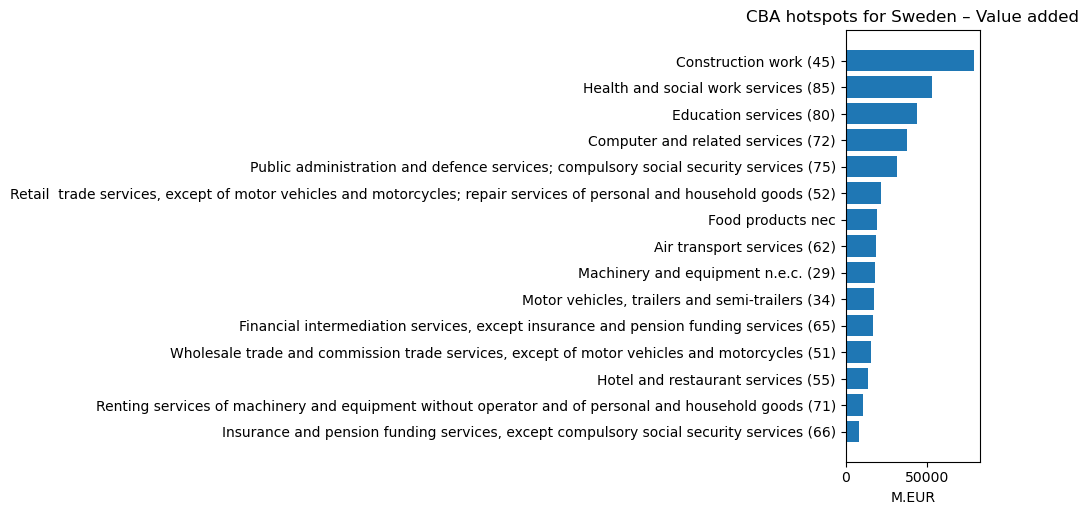

,account,indicator,region,sector,value,share_of_region_total,rank,unit,definition
0,CBA,materials,SE,Construction work (45),98092.271657,0.356855,1,kt,material
1,CBA,materials,SE,Precious metal ores and concentrates,23100.553768,0.084039,2,kt,material
2,CBA,materials,SE,Food products nec,12670.326253,0.046094,3,kt,material
3,CBA,materials,SE,Products of meat cattle,7352.273912,0.026747,4,kt,material
4,CBA,materials,SE,"Motor vehicles, trailers and semi-trailers (34)",6985.453600,0.025413,5,kt,material
5,CBA,materials,SE,Hotel and restaurant services (55),6954.924828,0.025302,6,kt,material
6,CBA,materials,SE,Health and social work services (85),6106.230717,0.022214,7,kt,material
7,CBA,materials,SE,Public administration and defence services; co...,5803.251104,0.021112,8,kt,material
8,CBA,materials,SE,Education services (80),5799.528545,0.021098,9,kt,material
9,CBA,materials,SE,Machinery and equipment n.e.c. (29),5591.612672,0.020342,10,kt,material


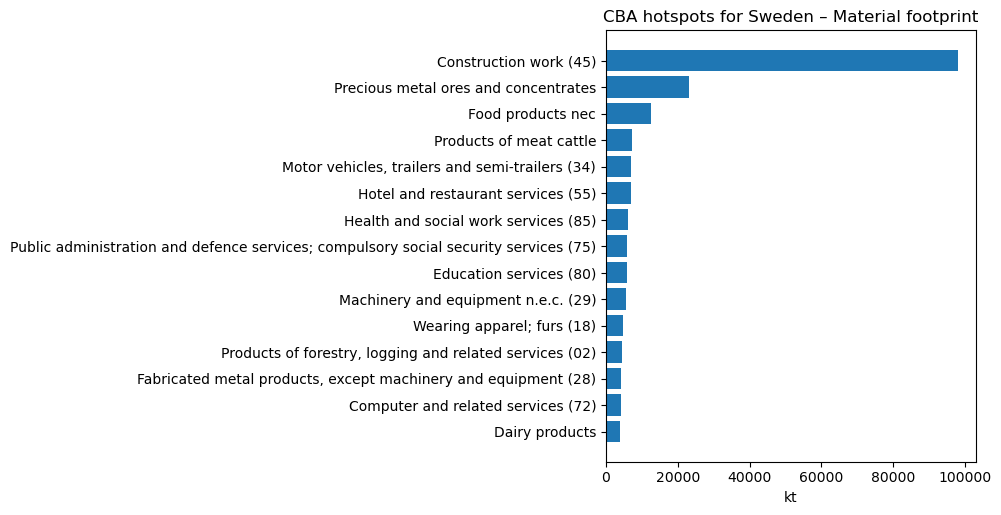

,account,indicator,region,sector,value,share_of_region_total,rank,unit,definition
0,CBA,ghg,SE,Hotel and restaurant services (55),1.177628e+11,0.148897,1,mass unit CO2-eq,proxy::raw_emissions
1,CBA,ghg,SE,Dairy products,1.097737e+11,0.138796,2,mass unit CO2-eq,proxy::raw_emissions
2,CBA,ghg,SE,"Retail trade services, except of motor vehicl...",5.783612e+10,0.073127,3,mass unit CO2-eq,proxy::raw_emissions
3,CBA,ghg,SE,Food products nec,5.547233e+10,0.070138,4,mass unit CO2-eq,proxy::raw_emissions
4,CBA,ghg,SE,Public administration and defence services; co...,4.715516e+10,0.059622,5,mass unit CO2-eq,proxy::raw_emissions
5,CBA,ghg,SE,Construction work (45),4.422693e+10,0.055920,6,mass unit CO2-eq,proxy::raw_emissions
6,CBA,ghg,SE,Computer and related services (72),3.213755e+10,0.040634,7,mass unit CO2-eq,proxy::raw_emissions
7,CBA,ghg,SE,Education services (80),3.097232e+10,0.039161,8,mass unit CO2-eq,proxy::raw_emissions
8,CBA,ghg,SE,Health and social work services (85),2.707293e+10,0.034230,9,mass unit CO2-eq,proxy::raw_emissions
9,CBA,ghg,SE,"Wholesale trade and commission trade services,...",2.598228e+10,0.032851,10,mass unit CO2-eq,proxy::raw_emissions


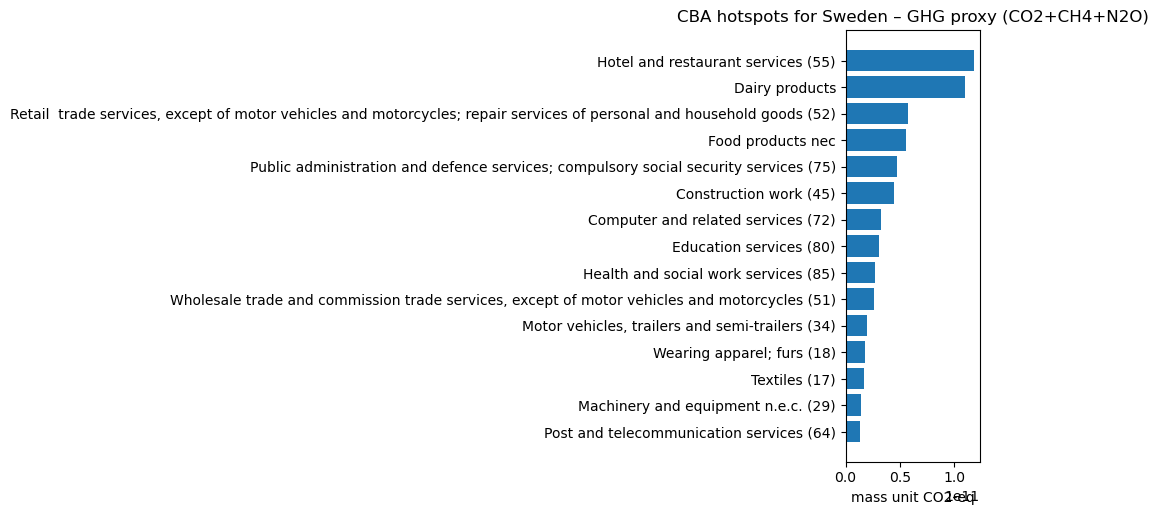

,account,indicator,region,sector,value,share_of_region_total,rank,unit,definition
0,PBA,economic_importance,SE,Other business services (74),43512.655769,0.077488,1,M.EUR,factor_inputs
1,PBA,economic_importance,SE,Other land transportation services,41714.192327,0.074286,2,M.EUR,factor_inputs
2,PBA,economic_importance,SE,Health and social work services (85),41549.748051,0.073993,3,M.EUR,factor_inputs
3,PBA,economic_importance,SE,Computer and related services (72),38792.172387,0.069082,4,M.EUR,factor_inputs
4,PBA,economic_importance,SE,Construction work (45),36702.379088,0.065361,5,M.EUR,factor_inputs
5,PBA,economic_importance,SE,Education services (80),28119.788818,0.050076,6,M.EUR,factor_inputs
6,PBA,economic_importance,SE,"Wholesale trade and commission trade services,...",24119.161945,0.042952,7,M.EUR,factor_inputs
7,PBA,economic_importance,SE,Public administration and defence services; co...,22277.396242,0.039672,8,M.EUR,factor_inputs
8,PBA,economic_importance,SE,Machinery and equipment n.e.c. (29),21778.644437,0.038784,9,M.EUR,factor_inputs
9,PBA,economic_importance,SE,"Financial intermediation services, except insu...",16378.248690,0.029167,10,M.EUR,factor_inputs


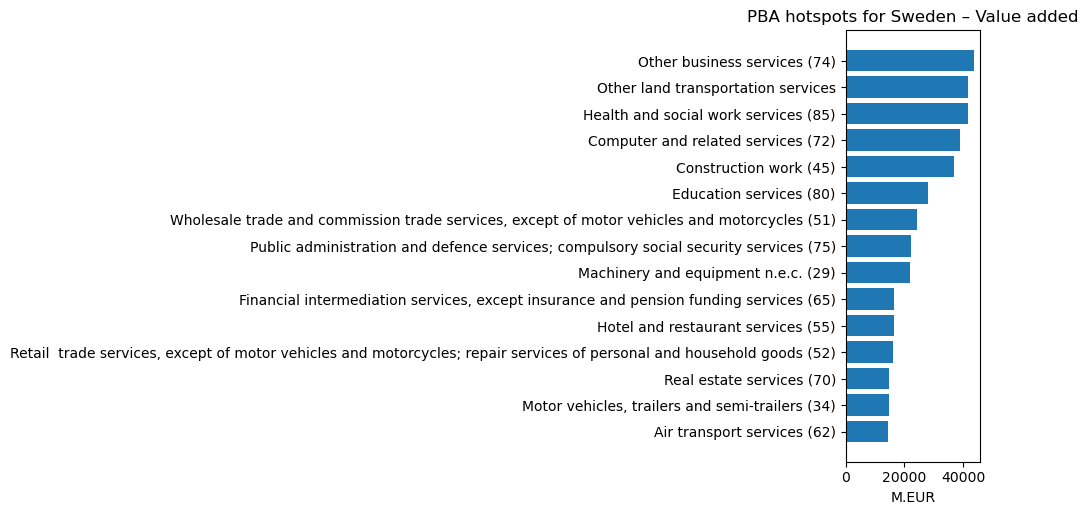

,account,indicator,region,sector,value,share_of_region_total,rank,unit,definition
0,PBA,materials,SE,Sand and clay,122575.241830,0.440087,1,kt,material
1,PBA,materials,SE,Iron ores,44252.629460,0.158882,2,kt,material
2,PBA,materials,SE,"Products of forestry, logging and related serv...",42530.261822,0.152698,3,kt,material
3,PBA,materials,SE,Copper ores and concentrates,26748.719274,0.096037,4,kt,material
4,PBA,materials,SE,Precious metal ores and concentrates,10459.636192,0.037554,5,kt,material
5,PBA,materials,SE,Cattle,7216.828360,0.025911,6,kt,material
6,PBA,materials,SE,Stone,6074.014678,0.021808,7,kt,material
7,PBA,materials,SE,"Lead, zinc and tin ores and concentrates",3769.924656,0.013535,8,kt,material
8,PBA,materials,SE,Wheat,3098.352459,0.011124,9,kt,material
9,PBA,materials,SE,"Sugar cane, sugar beet",2130.424197,0.007649,10,kt,material


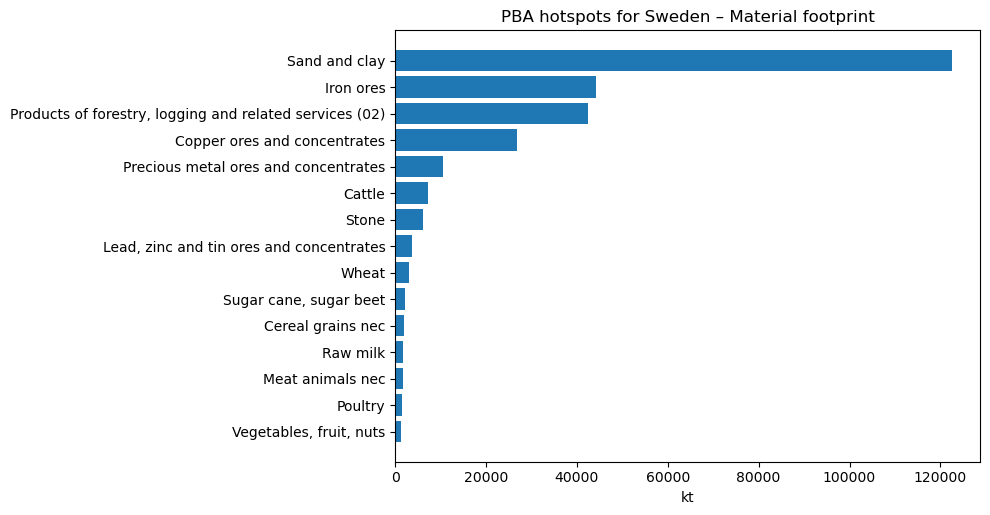

,account,indicator,region,sector,value,share_of_region_total,rank,unit,definition
0,PBA,ghg,SE,Paper for treatment: landfill,6.240571e+09,0.249205,1,mass unit CO2-eq,proxy::raw_emissions
1,PBA,ghg,SE,Food waste for treatment: landfill,5.943704e+09,0.237350,2,mass unit CO2-eq,proxy::raw_emissions
2,PBA,ghg,SE,Raw milk,3.909932e+09,0.156135,3,mass unit CO2-eq,proxy::raw_emissions
3,PBA,ghg,SE,Cattle,2.389100e+09,0.095404,4,mass unit CO2-eq,proxy::raw_emissions
4,PBA,ghg,SE,"Cement, lime and plaster",1.255051e+09,0.050118,5,mass unit CO2-eq,proxy::raw_emissions
5,PBA,ghg,SE,Cereal grains nec,1.064634e+09,0.042514,6,mass unit CO2-eq,proxy::raw_emissions
6,PBA,ghg,SE,Wheat,5.816359e+08,0.023226,7,mass unit CO2-eq,proxy::raw_emissions
7,PBA,ghg,SE,Plastic waste for treatment: landfill,4.789427e+08,0.019126,8,mass unit CO2-eq,proxy::raw_emissions
8,PBA,ghg,SE,Oil seeds,2.615530e+08,0.010445,9,mass unit CO2-eq,proxy::raw_emissions
9,PBA,ghg,SE,Pigs,2.276885e+08,0.009092,10,mass unit CO2-eq,proxy::raw_emissions


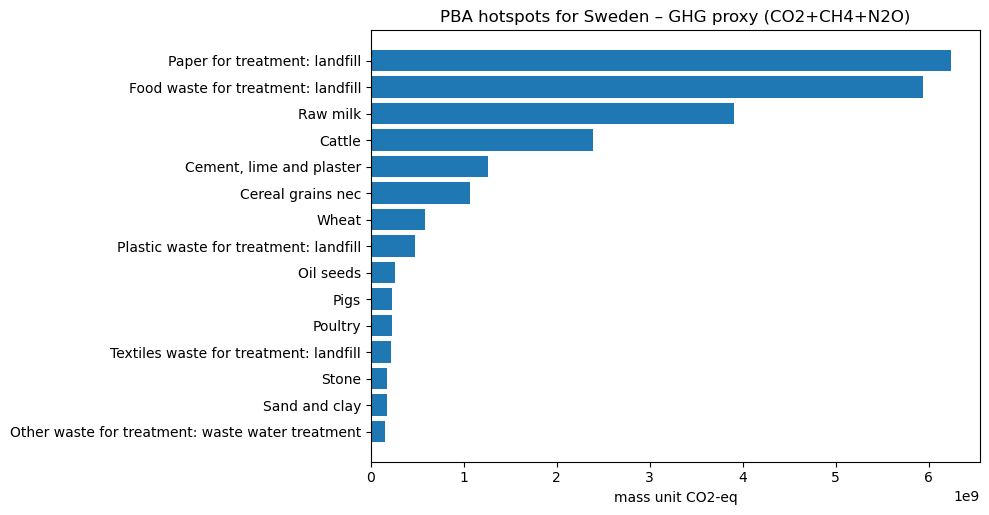

In [9]:
# Display top sectors by indicator and accounting principle
for account_name in ["CBA", "PBA"]:
    for indicator_name, spec in indicator_specs.items():
        title = f"{account_name} hotspots for Sweden – {spec['label']}"
        subset = (
            rankings
            .query("account == @account_name and indicator == @indicator_name")
            .sort_values("rank")
            .head(TOP_N_SECTORS)
            .reset_index(drop=True)
        )
        display(subset)
        plot_top_sectors(subset, title=title, top_n=TOP_N_SECTORS)



In [10]:

# Internal consistency checks and comparison against extension-stored accounts where available
ranking_checks = []
extension_vs_manual_checks = []
ghg_definition_comparison_summary = pd.DataFrame()
ghg_definition_comparison_details = pd.DataFrame()
ghg_proxy_rows_df = pd.DataFrame()
ghg_core_rows_df = pd.DataFrame()
ghg_sanity_df = pd.DataFrame()

for indicator_name, spec in indicator_specs.items():
    ext = spec["extension"]
    row_selector = spec["row_selector"]

    cba_total_rank = (
        rankings
        .query("account == 'CBA' and indicator == @indicator_name")
        ["value"]
        .sum()
    )
    pba_total_rank = (
        rankings
        .query("account == 'PBA' and indicator == @indicator_name")
        ["value"]
        .sum()
    )

    cba_total_manual = float(manual_cba_sector_vector(mrio, ext, row_selector, TARGET_REGION, Y_agg).sum())
    pba_total_manual = float(manual_pba_sector_vector(mrio, ext, row_selector, TARGET_REGION).sum())

    ranking_checks.append({
        "indicator": indicator_name,
        "account": "CBA",
        "ranking_sum": cba_total_rank,
        "manual_model_sum": cba_total_manual,
        "difference": cba_total_rank - cba_total_manual,
    })
    ranking_checks.append({
        "indicator": indicator_name,
        "account": "PBA",
        "ranking_sum": pba_total_rank,
        "manual_model_sum": pba_total_manual,
        "difference": pba_total_rank - pba_total_manual,
    })

    cmp_df = compare_extension_and_manual_accounts(
        mrio=mrio,
        ext=ext,
        row_selector=row_selector,
        target_region=TARGET_REGION,
        Y_agg=Y_agg,
        indicator_name=indicator_name,
    )
    if not cmp_df.empty:
        extension_vs_manual_checks.append(cmp_df)

ranking_checks = pd.DataFrame(ranking_checks)
display(ranking_checks)

if extension_vs_manual_checks:
    extension_vs_manual_checks = pd.concat(extension_vs_manual_checks, ignore_index=True)
    print("Manual accounts versus extension-stored accounts:")
    display(extension_vs_manual_checks)
else:
    extension_vs_manual_checks = pd.DataFrame()

if "ghg" in indicator_specs:
    ghg_sanity_df = ghg_sanity_check_table(
        rankings,
        indicator_key="ghg",
        suspicious_ratio=GHG_SUSPICIOUS_CBA_TO_PBA_RATIO,
    )
    print("GHG sanity check:")
    display(ghg_sanity_df)

if ghg_proxy_extension is not None and ghg_row_factors is not None:
    ghg_proxy_rows_df = ghg_proxy_row_diagnostics(
        mrio=mrio,
        emissions_ext=emissions_ext,
        row_factor_map=ghg_row_factors,
        target_region=TARGET_REGION,
        Y_agg=Y_agg,
    )
    print("GHG proxy totals by selected raw-emission row:")
    display(ghg_proxy_rows_df)

    ghg_core_rows_df = ghg_core_row_check_table(
        mrio=mrio,
        emissions_ext=emissions_ext,
        row_factor_map=ghg_row_factors,
        target_region=TARGET_REGION,
        Y_agg=Y_agg,
        core_rows=GHG_CORE_DIAGNOSTIC_ROWS,
    )
    print("GHG core-row diagnostic check:")
    display(ghg_core_rows_df)

if ghg_impact_extension is not None and ghg_proxy_extension is not None and GHG_COMPARE_PROXY_WHEN_IMPACT_AVAILABLE:
    impact_cba = manual_cba_sector_vector(mrio, ghg_impact_extension, ghg_impact_row, TARGET_REGION, Y_agg)
    impact_pba = manual_pba_sector_vector(mrio, ghg_impact_extension, ghg_impact_row, TARGET_REGION)
    proxy_cba = manual_cba_sector_vector(mrio, ghg_proxy_extension, ghg_proxy_row_selector, TARGET_REGION, Y_agg)
    proxy_pba = manual_pba_sector_vector(mrio, ghg_proxy_extension, ghg_proxy_row_selector, TARGET_REGION)

    cba_summary, cba_details = compare_two_sector_vectors(
        impact_cba,
        proxy_cba,
        label_a="impact",
        label_b="proxy",
        top_n=TOP_N_SECTORS,
    )
    cba_summary["account"] = "CBA"
    pba_summary, pba_details = compare_two_sector_vectors(
        impact_pba,
        proxy_pba,
        label_a="impact",
        label_b="proxy",
        top_n=TOP_N_SECTORS,
    )
    pba_summary["account"] = "PBA"

    ghg_definition_comparison_summary = pd.concat([cba_summary, pba_summary], ignore_index=True)
    cba_details["account"] = "CBA"
    pba_details["account"] = "PBA"
    ghg_definition_comparison_details = pd.concat([cba_details, pba_details], ignore_index=True)

    print("GHG definition comparison: characterized impact versus raw-emissions proxy")
    display(ghg_definition_comparison_summary)

    print("GHG definition comparison details (top rows sorted by proxy value)")
    display(ghg_definition_comparison_details.head(30))

ghg_sanity_df.to_csv(OUTPUT_DIR / "ghg_sanity_check.csv", index=False)
ghg_proxy_rows_df.to_csv(OUTPUT_DIR / "ghg_proxy_row_diagnostics.csv", index=False)
ghg_core_rows_df.to_csv(OUTPUT_DIR / "ghg_core_row_diagnostics.csv", index=False)
ghg_definition_comparison_summary.to_csv(OUTPUT_DIR / "ghg_definition_comparison_summary.csv", index=False)
ghg_definition_comparison_details.to_csv(OUTPUT_DIR / "ghg_definition_comparison_details.csv", index=False)


,indicator,account,ranking_sum,manual_model_sum,difference
0,economic_importance,CBA,5.379344e+05,5.379344e+05,0.0
1,economic_importance,PBA,5.615370e+05,5.615370e+05,0.0
2,materials,CBA,2.748797e+05,2.748797e+05,0.0
3,materials,PBA,2.785248e+05,2.785248e+05,0.0
4,ghg,CBA,7.909016e+11,7.909016e+11,0.0
5,ghg,PBA,2.504193e+10,2.504193e+10,0.0


Manual accounts versus extension-stored accounts:


,indicator,account,manual_total,extension_total,difference,relative_difference
0,economic_importance,CBA,537934.438686,537934.438686,-1.164153e-10,-2.164117e-16
1,economic_importance,PBA,561536.969934,561536.969934,9.022187e-08,1.606695e-13
2,materials,CBA,274879.669258,274879.669258,0.000000e+00,0.000000e+00
3,materials,PBA,278524.762272,278524.762272,3.462192e-07,1.243046e-12


GHG sanity check:


,indicator,cba_total,pba_total,cba_to_pba_ratio,suspicious_ratio_threshold,ratio_exceeds_threshold,top_cba_sector,top_cba_sector_share,top_pba_sector,top_pba_sector_share
0,ghg,7.909016e+11,2.504193e+10,31.583095,5.0,True,Hotel and restaurant services (55),0.148897,Paper for treatment: landfill,0.249205


GHG proxy totals by selected raw-emission row:


,raw_row,factor,cba_total_weighted,pba_total_weighted,cba_share_of_proxy_total,pba_share_of_proxy_total
0,CO2 - combustion - air,1.0,0.0,0.000000e+00,NaN,0.000000
1,CO2 - non combustion - Cement production - air,1.0,0.0,1.203942e+09,NaN,0.048077
2,CO2 - non combustion - Lime production - air,1.0,0.0,4.571182e+08,NaN,0.018254
3,CO2 - agriculture - peat decay - air,1.0,0.0,1.614458e+08,NaN,0.006447
4,CO2 - waste - fossil - air,1.0,0.0,1.254493e+06,NaN,0.000050
5,CH4 - combustion - air,28.0,0.0,0.000000e+00,NaN,0.000000
6,CH4 - non combustion - Extraction/production o...,28.0,0.0,2.032407e+07,NaN,0.000812
7,CH4 - non combustion - Extraction/production o...,28.0,0.0,4.616274e+05,NaN,0.000018
8,CH4 - non combustion - Mining of antracite - air,28.0,0.0,1.681498e+05,NaN,0.000007
9,CH4 - non combustion - Mining of bituminous co...,28.0,0.0,1.027230e+05,NaN,0.000004


GHG core-row diagnostic check:


,raw_row,selected_in_proxy,factor,cba_total_weighted,pba_total_weighted,both_zero,warning
0,CO2 - combustion - air,True,1.0,0.0,0.0,True,selected but zero in both CBA and PBA
1,CH4 - combustion - air,True,28.0,0.0,0.0,True,selected but zero in both CBA and PBA
2,N2O - combustion - air,True,265.0,0.0,0.0,True,selected but zero in both CBA and PBA


In [11]:
# Build country breakdowns for hotspot sectors
cba_source_tables_full = []
cba_source_tables_shown = []
pba_destination_tables_full = []
pba_destination_tables_shown = []

for indicator_name, spec in indicator_specs.items():
    ext = spec["extension"]
    row_selector = spec["row_selector"]
    unit = spec["unit"]

    cba_hotspots = (
        rankings
        .query("account == 'CBA' and indicator == @indicator_name")
        .sort_values("rank")
        .head(TOP_N_SOURCE_SECTORS)
        .copy()
    )

    for _, row in cba_hotspots.iterrows():
        sector = row["sector"]
        sector_value = row["value"]

        src_full, src_shown = cba_source_country_shares(
            mrio=mrio,
            ext=ext,
            row_selector=row_selector,
            target_region=TARGET_REGION,
            target_sector=sector,
            Y_agg=Y_agg,
            top_n=TOP_N_SOURCE_COUNTRIES,
        )

        for df in [src_full, src_shown]:
            df["indicator"] = indicator_name
            df["target_sector_value"] = sector_value
            df["unit"] = unit

        cba_source_tables_full.append(src_full)
        cba_source_tables_shown.append(src_shown)

    pba_hotspots = (
        rankings
        .query("account == 'PBA' and indicator == @indicator_name")
        .sort_values("rank")
        .head(TOP_N_SOURCE_SECTORS)
        .copy()
    )

    for _, row in pba_hotspots.iterrows():
        sector = row["sector"]
        sector_value = row["value"]

        dest_full, dest_shown = pba_destination_country_shares(
            mrio=mrio,
            ext=ext,
            row_selector=row_selector,
            source_region=TARGET_REGION,
            source_sector=sector,
            Y_agg=Y_agg,
            top_n=TOP_N_DESTINATION_COUNTRIES,
        )

        for df in [dest_full, dest_shown]:
            df["indicator"] = indicator_name
            df["source_sector_value"] = sector_value
            df["unit"] = unit

        pba_destination_tables_full.append(dest_full)
        pba_destination_tables_shown.append(dest_shown)

cba_source_country_shares_full_df = pd.concat(cba_source_tables_full, ignore_index=True)
cba_source_country_shares_df = pd.concat(cba_source_tables_shown, ignore_index=True)
pba_destination_country_shares_full_df = pd.concat(pba_destination_tables_full, ignore_index=True)
pba_destination_country_shares_df = pd.concat(pba_destination_tables_shown, ignore_index=True)

cba_breakdown_checks = summarise_breakdown_quality(
    cba_source_country_shares_full_df,
    group_cols=["indicator", "target_region", "target_sector"],
    value_col="source_value",
    total_col="model_total",
    reference_total_col="target_sector_value",
    share_col="source_share",
).sort_values(["indicator", "target_sector"])

pba_destination_checks = summarise_breakdown_quality(
    pba_destination_country_shares_full_df,
    group_cols=["indicator", "source_region", "source_sector"],
    value_col="destination_value",
    total_col="model_total",
    reference_total_col="source_sector_value",
    share_col="destination_share",
).sort_values(["indicator", "source_sector"])

cba_source_country_shares_df.to_csv(OUTPUT_DIR / "sweden_cba_source_country_shares_top.csv", index=False)
cba_source_country_shares_full_df.to_csv(OUTPUT_DIR / "sweden_cba_source_country_shares_full.csv", index=False)
pba_destination_country_shares_df.to_csv(OUTPUT_DIR / "sweden_pba_destination_country_shares_top.csv", index=False)
pba_destination_country_shares_full_df.to_csv(OUTPUT_DIR / "sweden_pba_destination_country_shares_full.csv", index=False)
cba_breakdown_checks.to_csv(OUTPUT_DIR / "sweden_cba_source_country_checks.csv", index=False)
pba_destination_checks.to_csv(OUTPUT_DIR / "sweden_pba_destination_country_checks.csv", index=False)

print("CBA source-country shares (shown table, first 30 rows):")
display(cba_source_country_shares_df.head(30))

print("CBA source-country closure checks (based on full tables):")
display(cba_breakdown_checks)

print("PBA destination-country shares (final-demand destinations; shown table, first 30 rows):")
display(pba_destination_country_shares_df.head(30))

print("PBA final-demand destination-country closure checks (based on full tables):")
display(pba_destination_checks)

print(f"Saved: {OUTPUT_DIR / 'sweden_cba_source_country_shares_top.csv'}")
print(f"Saved: {OUTPUT_DIR / 'sweden_cba_source_country_shares_full.csv'}")
print(f"Saved: {OUTPUT_DIR / 'sweden_pba_destination_country_shares_top.csv'}")
print(f"Saved: {OUTPUT_DIR / 'sweden_pba_destination_country_shares_full.csv'}")


CBA source-country shares (shown table, first 30 rows):


,target_region,target_sector,source_country,source_value,source_share,model_total,residual_to_model_total,indicator,target_sector_value,unit
0,SE,Construction work (45),SE,59410.562035,0.757213,78459.545212,0.0,economic_importance,78459.545212,M.EUR
1,SE,Construction work (45),NO,1852.710645,0.023614,78459.545212,0.0,economic_importance,78459.545212,M.EUR
2,SE,Construction work (45),DE,1800.361905,0.022946,78459.545212,0.0,economic_importance,78459.545212,M.EUR
3,SE,Construction work (45),GB,1464.477819,0.018665,78459.545212,0.0,economic_importance,78459.545212,M.EUR
4,SE,Construction work (45),US,1447.136687,0.018444,78459.545212,0.0,economic_importance,78459.545212,M.EUR
5,SE,Construction work (45),WA,1130.528373,0.014409,78459.545212,0.0,economic_importance,78459.545212,M.EUR
6,SE,Construction work (45),CN,1024.390843,0.013056,78459.545212,0.0,economic_importance,78459.545212,M.EUR
7,SE,Construction work (45),DK,890.845468,0.011354,78459.545212,0.0,economic_importance,78459.545212,M.EUR
8,SE,Construction work (45),NL,886.543912,0.011299,78459.545212,0.0,economic_importance,78459.545212,M.EUR
9,SE,Construction work (45),FR,733.885961,0.009354,78459.545212,0.0,economic_importance,78459.545212,M.EUR


CBA source-country closure checks (based on full tables):


,indicator,target_region,target_sector,reconstructed_total,model_total,min_contribution,max_contribution,negative_contribution_count,reference_total,share_sum,abs_difference,relative_difference,passes_model_total_check,difference_to_reference,relative_difference_to_reference,passes_reference_check,share_sum_difference_from_1,passes_share_sum_check
0,economic_importance,SE,Computer and related services (72),3.739832e+04,3.739832e+04,8.551029,2.719396e+04,0,3.739832e+04,1.0,0.000000e+00,0.000000e+00,True,-2.182787e-11,-5.836591e-16,True,-1.110223e-16,True
1,economic_importance,SE,Construction work (45),7.845955e+04,7.845955e+04,15.515851,5.941056e+04,0,7.845955e+04,1.0,0.000000e+00,0.000000e+00,True,-7.275958e-11,-9.273515e-16,True,0.000000e+00,True
2,economic_importance,SE,Education services (80),4.402666e+04,4.402666e+04,7.454083,3.704784e+04,0,4.402666e+04,1.0,7.275958e-12,1.652625e-16,True,-2.182787e-11,-4.957876e-16,True,2.220446e-16,True
3,economic_importance,SE,Health and social work services (85),5.275235e+04,5.275235e+04,6.046996,4.606356e+04,0,5.275235e+04,1.0,0.000000e+00,0.000000e+00,True,3.637979e-11,6.896335e-16,True,0.000000e+00,True
4,economic_importance,SE,Public administration and defence services; co...,3.164341e+04,3.164341e+04,8.024260,2.559255e+04,0,3.164341e+04,1.0,0.000000e+00,0.000000e+00,True,2.910383e-11,9.197438e-16,True,0.000000e+00,True
5,ghg,SE,Dairy products,1.097737e+11,1.097737e+11,29121.412426,1.065265e+11,0,1.097737e+11,1.0,-3.051758e-05,-2.780045e-16,True,-4.577637e-05,-4.170067e-16,True,-2.220446e-16,True
6,ghg,SE,Food products nec,5.547233e+10,5.547233e+10,55589.885234,5.302228e+10,0,5.547233e+10,1.0,-7.629395e-06,-1.375351e-16,True,6.866455e-05,1.237816e-15,True,0.000000e+00,True
7,ghg,SE,Hotel and restaurant services (55),1.177628e+11,1.177628e+11,201260.090476,1.164661e+11,0,1.177628e+11,1.0,0.000000e+00,0.000000e+00,True,1.068115e-04,9.070056e-16,True,0.000000e+00,True
8,ghg,SE,Public administration and defence services; co...,4.715516e+10,4.715516e+10,260548.131896,4.630041e+10,0,4.715516e+10,1.0,0.000000e+00,0.000000e+00,True,7.629395e-05,1.617934e-15,True,0.000000e+00,True
9,ghg,SE,"Retail trade services, except of motor vehicl...",5.783612e+10,5.783612e+10,170372.196124,5.731010e+10,0,5.783612e+10,1.0,7.629395e-06,1.319140e-16,True,5.340576e-05,9.233981e-16,True,2.220446e-16,True


PBA destination-country shares (final-demand destinations; shown table, first 30 rows):


,source_region,source_sector,destination_country,destination_value,destination_share,model_total,residual_to_model_total,indicator,source_sector_value,unit
0,SE,Other business services (74),SE,16689.433252,0.383554,43512.655769,0.0,economic_importance,43512.655769,M.EUR
1,SE,Other business services (74),US,2875.812437,0.066091,43512.655769,0.0,economic_importance,43512.655769,M.EUR
2,SE,Other business services (74),FR,2103.522881,0.048343,43512.655769,0.0,economic_importance,43512.655769,M.EUR
3,SE,Other business services (74),CN,1898.287160,0.043626,43512.655769,0.0,economic_importance,43512.655769,M.EUR
4,SE,Other business services (74),DE,1693.562715,0.038921,43512.655769,0.0,economic_importance,43512.655769,M.EUR
5,SE,Other business services (74),CH,1268.281264,0.029147,43512.655769,0.0,economic_importance,43512.655769,M.EUR
6,SE,Other business services (74),GB,1236.661452,0.028421,43512.655769,0.0,economic_importance,43512.655769,M.EUR
7,SE,Other business services (74),DK,1204.836023,0.027689,43512.655769,0.0,economic_importance,43512.655769,M.EUR
8,SE,Other business services (74),WA,1152.864728,0.026495,43512.655769,0.0,economic_importance,43512.655769,M.EUR
9,SE,Other business services (74),NO,1010.665778,0.023227,43512.655769,0.0,economic_importance,43512.655769,M.EUR


PBA final-demand destination-country closure checks (based on full tables):


,indicator,source_region,source_sector,reconstructed_total,model_total,min_contribution,max_contribution,negative_contribution_count,reference_total,share_sum,abs_difference,relative_difference,passes_model_total_check,difference_to_reference,relative_difference_to_reference,passes_reference_check,share_sum_difference_from_1,passes_share_sum_check
0,economic_importance,SE,Computer and related services (72),3.879217e+04,3.879217e+04,2.962949e+00,2.614677e+04,0,3.879217e+04,1.0,-7.275958e-12,-1.875625e-16,True,5.289621e-09,1.363580e-13,True,-2.220446e-16,True
1,economic_importance,SE,Construction work (45),3.670238e+04,3.670238e+04,2.236897e-01,3.484096e+04,0,3.670238e+04,1.0,0.000000e+00,0.000000e+00,True,-2.635352e-08,-7.180330e-13,True,0.000000e+00,True
2,economic_importance,SE,Health and social work services (85),4.154975e+04,4.154975e+04,6.146004e-02,4.076679e+04,0,4.154975e+04,1.0,0.000000e+00,0.000000e+00,True,-3.565219e-10,-8.580604e-15,True,0.000000e+00,True
3,economic_importance,SE,Other business services (74),4.351266e+04,4.351266e+04,9.278859e+00,1.668943e+04,0,4.351266e+04,1.0,0.000000e+00,0.000000e+00,True,-2.774323e-08,-6.375898e-13,True,0.000000e+00,True
4,economic_importance,SE,Other land transportation services,4.171419e+04,4.171419e+04,2.683767e+00,2.229302e+04,0,4.171419e+04,1.0,-7.275958e-12,-1.744240e-16,True,-8.090865e-09,-1.939595e-13,True,-1.110223e-16,True
5,ghg,SE,Cattle,2.389100e+09,2.389100e+09,5.583458e+04,1.986242e+09,0,2.389100e+09,1.0,0.000000e+00,0.000000e+00,True,-2.343655e-03,-9.809780e-13,True,0.000000e+00,True
6,ghg,SE,"Cement, lime and plaster",1.255051e+09,1.255051e+09,2.201101e+04,1.089080e+09,0,1.255051e+09,1.0,0.000000e+00,0.000000e+00,True,-4.475117e-04,-3.565685e-13,True,0.000000e+00,True
7,ghg,SE,Food waste for treatment: landfill,5.943704e+09,5.943704e+09,1.243866e+06,1.891667e+09,0,5.943704e+09,1.0,9.536743e-07,1.604512e-16,True,-9.387970e-03,-1.579481e-12,True,0.000000e+00,True
8,ghg,SE,Paper for treatment: landfill,6.240571e+09,6.240571e+09,1.228287e+06,2.116726e+09,0,6.240571e+09,1.0,9.536743e-07,1.528184e-16,True,7.801056e-04,1.250055e-13,True,2.220446e-16,True
9,ghg,SE,Raw milk,3.909932e+09,3.909932e+09,1.073140e+05,2.946497e+09,0,3.909932e+09,1.0,-4.768372e-07,-1.219554e-16,True,-1.365423e-02,-3.492192e-12,True,0.000000e+00,True


Saved: c:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\exiobase3_sweden_hotspot_outputs\sweden_cba_source_country_shares_top.csv
Saved: c:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\exiobase3_sweden_hotspot_outputs\sweden_cba_source_country_shares_full.csv
Saved: c:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\exiobase3_sweden_hotspot_outputs\sweden_pba_destination_country_shares_top.csv
Saved: c:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\exiobase3_sweden_hotspot_outputs\sweden_pba_destination_country_shares_full.csv


In [12]:
# Optional: compact wide-format exports for easy browsing in Excel
rankings_wide = (
    rankings
    .pivot_table(
        index=["region", "sector"],
        columns=["account", "indicator"],
        values="value",
        aggfunc="first",
    )
    .sort_index(axis=1)
)

cba_source_shares_wide = (
    cba_source_country_shares_df
    .pivot_table(
        index=["indicator", "target_region", "target_sector"],
        columns="source_country",
        values="source_share",
        aggfunc="first",
    )
    .sort_index(axis=1)
)

pba_destination_shares_wide = (
    pba_destination_country_shares_df
    .pivot_table(
        index=["indicator", "source_region", "source_sector"],
        columns="destination_country",
        values="destination_share",
        aggfunc="first",
    )
    .sort_index(axis=1)
)

with pd.ExcelWriter(OUTPUT_DIR / "sweden_hotspot_analysis.xlsx", engine="openpyxl") as writer:
    rankings.to_excel(writer, sheet_name="rankings_tidy", index=False)
    rankings_wide.to_excel(writer, sheet_name="rankings_wide")
    cba_source_country_shares_df.to_excel(writer, sheet_name="cba_source_shares", index=False)
    cba_source_shares_wide.to_excel(writer, sheet_name="cba_source_shares_wide")
    cba_breakdown_checks.to_excel(writer, sheet_name="cba_source_checks", index=False)
    pba_destination_country_shares_df.to_excel(writer, sheet_name="pba_dest_shares", index=False)
    pba_destination_shares_wide.to_excel(writer, sheet_name="pba_dest_shares_wide")
    pba_destination_checks.to_excel(writer, sheet_name="pba_dest_checks", index=False)

rankings.to_csv(OUTPUT_DIR / "sweden_sector_rankings_tidy.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'sweden_hotspot_analysis.xlsx'}")



# Additional GHG diagnostics
with pd.ExcelWriter(OUTPUT_DIR / "sweden_hotspot_analysis.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    ghg_sanity_df.to_excel(writer, sheet_name="ghg_sanity_check", index=False)
    ghg_proxy_rows_df.to_excel(writer, sheet_name="ghg_proxy_rows", index=False)
    ghg_definition_comparison_summary.to_excel(writer, sheet_name="ghg_def_compare_sum", index=False)
    ghg_definition_comparison_details.to_excel(writer, sheet_name="ghg_def_compare_det", index=False)
print(f"Updated workbook with GHG diagnostics: {OUTPUT_DIR / 'sweden_hotspot_analysis.xlsx'}")


Saved: c:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\exiobase3_sweden_hotspot_outputs\sweden_hotspot_analysis.xlsx
Updated workbook with GHG diagnostics: c:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\exiobase3_sweden_hotspot_outputs\sweden_hotspot_analysis.xlsx


# Notes for interpretation

- **CBA rankings** show which Swedish final-demand sectors are associated with the largest global value added, GHG burden, or material footprint.
- **PBA rankings** show which Swedish production sectors account for the largest direct impacts occurring in Sweden.
- **CBA source-country shares** trace the hotspot sector back to the countries where the direct value added / emissions / material extraction occur in the supply chain.
- **PBA destination-country shares** allocate a Swedish production hotspot across the destination countries whose final demand induces that Swedish output.
- For **PBA source country**, the answer is trivially Sweden = 100%; the destination breakdown is more informative, so it is reported explicitly.
- The notebook now includes reconstruction checks so you can see whether the country decomposition reproduces the corresponding model total.
- If the notebook is rerun after an error, restart the kernel and run from the top to avoid stale outputs remaining in later cells.


- **PBA destination-country tables** allocate Sweden's *direct* production-based burdens to the countries whose **final demand** ultimately drives that Swedish output. They are not the same as direct export-partner statistics.
- **Closure checks** should be read with the pass/fail columns. Tiny residuals around machine precision are numerical noise, not substantive inconsistencies.

- **GHG results** are only directly comparable across runs when they use the same definition. If one run uses a characterized `impacts` row and another uses the raw-emissions proxy, compare them only after inspecting the new GHG diagnostic tables.


## Files written by this notebook

The notebook writes the following files to `OUTPUT_DIR`:

- `sweden_sector_rankings_tidy.csv`
- `sweden_cba_source_country_shares.csv`
- `sweden_pba_destination_country_shares.csv`
- `sweden_cba_source_country_checks.csv`
- `sweden_pba_destination_country_checks.csv`
- `sweden_hotspot_analysis.xlsx`


In [14]:
# for Claude
# 1) Unit of each selected proxy row, straight from the extension
units_report = pd.DataFrame([
    {
        "row": row_to_text(r),
        "factor": f,
        "unit": str(detect_common_unit(emissions_ext, r) or "<unknown>"),
    }
    for r, f in ghg_row_factors.items()
])
display(units_report)

# 2) Per-row PBA and CBA computed the SAME way the ranking is computed
# (this is the aggregate, not per-row-isolated-proxy).
S_full = selected_S_vector(ghg_extension, ghg_row_selector)  # characterized S
pba_full = float((S_full * get_output_vector(mrio)).sum())
M_full = S_full.dot(mrio.L)
cba_full_SE = float((M_full * as_series(Y_agg["SE"])).sum())
print("Aggregate proxy PBA (global):", pba_full)
print("Aggregate proxy CBA for SE  :", cba_full_SE)

# 3) Same thing, but for EACH selected row taken ALONE, through the ranking path
import numpy as np
rows = []
for raw_row, factor in ghg_row_factors.items():
    S_row = select_rows(emissions_ext.S, raw_row).iloc[0].astype(float) * float(factor)
    pba_row = float((S_row * get_output_vector(mrio)).sum())
    M_row = S_row.dot(mrio.L)
    cba_row_SE = float((M_row * as_series(Y_agg["SE"])).sum())
    rows.append({
        "row": row_to_text(raw_row),
        "factor": factor,
        "unit": str(detect_common_unit(emissions_ext, raw_row) or "<unknown>"),
        "pba_global": pba_row,
        "cba_SE": cba_row_SE,
    })
per_row = pd.DataFrame(rows).sort_values("cba_SE", ascending=False).reset_index(drop=True)
display(per_row)
print("Sum of per-row CBA_SE:", per_row["cba_SE"].sum())
print("Should equal aggregate CBA for SE:", cba_full_SE)

,row,factor,unit
0,CO2 - combustion - air,1.0,kg
1,CO2 - non combustion - Cement production - air,1.0,kg
2,CO2 - non combustion - Lime production - air,1.0,kg
3,CO2 - agriculture - peat decay - air,1.0,kg
4,CO2 - waste - fossil - air,1.0,kg
5,CH4 - combustion - air,28.0,kg
6,CH4 - non combustion - Extraction/production o...,28.0,kg
7,CH4 - non combustion - Extraction/production o...,28.0,kg
8,CH4 - non combustion - Mining of antracite - air,28.0,kg
9,CH4 - non combustion - Mining of bituminous co...,28.0,kg


Aggregate proxy PBA (global): 217611917335262.53
Aggregate proxy CBA for SE  : 790901642662.4291


,row,factor,unit,pba_global,cba_SE
0,CO2 - combustion - air,1.0,kg,0.000000e+00,0.0
1,CO2 - non combustion - Cement production - air,1.0,kg,1.618179e+12,0.0
2,CO2 - non combustion - Lime production - air,1.0,kg,2.266955e+11,0.0
3,CO2 - agriculture - peat decay - air,1.0,kg,2.220603e+12,0.0
4,CO2 - waste - fossil - air,1.0,kg,4.562925e+08,0.0
5,CH4 - combustion - air,28.0,kg,0.000000e+00,0.0
6,CH4 - non combustion - Extraction/production o...,28.0,kg,7.119200e+11,0.0
7,CH4 - non combustion - Extraction/production o...,28.0,kg,1.496061e+12,0.0
8,CH4 - non combustion - Mining of antracite - air,28.0,kg,1.422358e+10,0.0
9,CH4 - non combustion - Mining of bituminous co...,28.0,kg,1.006547e+12,0.0


Sum of per-row CBA_SE: 0.0
Should equal aggregate CBA for SE: 790901642662.4291


In [15]:
print(per_row.to_string())

                                                                    row  factor       unit    pba_global  cba_SE
0                                                CO2 - combustion - air     1.0         kg  0.000000e+00     0.0
1                        CO2 - non combustion - Cement production - air     1.0         kg  1.618179e+12     0.0
2                          CO2 - non combustion - Lime production - air     1.0         kg  2.266955e+11     0.0
3                                  CO2 - agriculture - peat decay - air     1.0         kg  2.220603e+12     0.0
4                                            CO2 - waste - fossil - air     1.0         kg  4.562925e+08     0.0
5                                                CH4 - combustion - air    28.0         kg  0.000000e+00     0.0
6   CH4 - non combustion - Extraction/production of (natural) gas - air    28.0         kg  7.119200e+11     0.0
7       CH4 - non combustion - Extraction/production of crude oil - air    28.0         kg  1.49

In [16]:
import numpy as np

# 1) Confirm Σ S_row equals S_full at the vector level
S_full = selected_S_vector(ghg_extension, ghg_row_selector)
S_sum = None
for r, f in ghg_row_factors.items():
    piece = select_rows(emissions_ext.S, r).iloc[0].astype(float) * float(f)
    S_sum = piece if S_sum is None else S_sum.add(piece, fill_value=0.0)

print("len(S_full):", len(S_full), " len(S_sum):", len(S_sum))
print("S_full.index.equals(S_sum.index):", S_full.index.equals(S_sum.index))
print("S_full.index.names:", S_full.index.names)
print("S_sum.index.names :", S_sum.index.names)
print("max |S_full - S_sum|:", float((S_full - S_sum).abs().max()))
print("S_full.sum():", float(S_full.sum()))
print("S_sum.sum() :", float(S_sum.sum()))

# 2) CBA for SE computed purely on numpy arrays, no alignment
# Align S_full onto mrio.L.index first so we compare apples to apples
S_aligned = S_full.reindex(mrio.L.index).fillna(0.0).values
L_arr = mrio.L.values
y_SE_arr = as_series(Y_agg["SE"]).reindex(mrio.L.index).fillna(0.0).values

cba_numpy = float((S_aligned @ L_arr) @ y_SE_arr)
print("CBA_SE via numpy (S_full aligned to L.index):", cba_numpy)

# 3) Same thing via the Series path
M_full = S_full.dot(mrio.L)
print("M_full.index.names:", M_full.index.names)
print("y_SE.index.names   :", as_series(Y_agg['SE']).index.names)
print("M_full.index equals y_SE.index?", M_full.index.equals(as_series(Y_agg['SE']).index))
cba_series = float((M_full * as_series(Y_agg["SE"])).sum())
print("CBA_SE via Series path:", cba_series)

# 4) Per-row, with the SAME alignment step applied
cba_per_row_aligned = 0.0
for r, f in ghg_row_factors.items():
    S_row = select_rows(emissions_ext.S, r).iloc[0].astype(float) * float(f)
    S_row_arr = S_row.reindex(mrio.L.index).fillna(0.0).values
    cba_per_row_aligned += float((S_row_arr @ L_arr) @ y_SE_arr)
print("Σ per-row CBA_SE via numpy+alignment:", cba_per_row_aligned)

len(S_full): 9800  len(S_sum): 9800
S_full.index.equals(S_sum.index): True
S_full.index.names: ['region', 'sector']
S_sum.index.names : ['region', 'sector']
max |S_full - S_sum|: 3.814697265625e-06
S_full.sum(): 150581584338.56082
S_sum.sum() : 150581584338.56082
CBA_SE via numpy (S_full aligned to L.index): 790901642662.429
M_full.index.names: ['region', 'sector']
y_SE.index.names   : ['region', 'sector']
M_full.index equals y_SE.index? True
CBA_SE via Series path: 790901642662.4291
Σ per-row CBA_SE via numpy+alignment: 790901642662.4297
